# 📊 Multi-Factor Fundamental Stock Screener

---

## 1. Project Overview

This notebook builds a **quantitative fundamental screener** that ranks ~500 S&P 500 stocks across three factor pillars:

| Pillar | Metrics | Weight |
|--------|---------|--------|
| **Value** | P/E, EV/EBITDA, P/B, P/FCF | 33% |
| **Quality** | ROE, ROIC, Gross Margin Stability, Debt/Equity | 33% |
| **Growth** | Revenue CAGR (3yr), EPS CAGR (3yr), FCF Growth | 34% |

Each stock receives a **composite Z-score** (0–100), producing a ranked watchlist.

---

## 2. Real-World Finance Use Case

- **Equity research analysts** use multi-factor models to surface high-conviction ideas from large universes before deeper fundamental diligence.
- **Quantitative PMs** use composite factor scores as signals in systematic long/short strategies.
- **Retail investors** use screeners to build a shortlist of quality-at-a-reasonable-price (QARP) candidates.

---

## 3. System Architecture

```
S&P 500 Universe (~503 tickers)
        │
        ▼
  [Data Collection]
  yfinance → income stmt, balance sheet, cash flow, quote
        │
        ▼
  [Data Cleaning & Feature Engineering]
  Normalize, handle NaN, compute derived metrics
        │
        ▼
  [Factor Computation]
  Value Score │ Quality Score │ Growth Score
        │
        ▼
  [Z-Score Normalization & Composite Ranking]
        │
        ▼
  [Visualization & Dashboard]
  Factor heatmaps, scatter plots, ranked table
        │
        ▼
  [Export: CSV + Excel Watchlist]
```

---

## 4. Required APIs & Data Sources

| Source | Usage | Cost |
|--------|-------|------|
| **Yahoo Finance** (`yfinance`) | Financials, price, market cap | Free |
| **Wikipedia** | S&P 500 constituent list | Free |

---

## 5. Required Python Libraries

```
yfinance, pandas, numpy, scipy, matplotlib, seaborn, plotly, openpyxl, tqdm, requests, lxml
```

---
# ⚙️ CELL 1 — Install Dependencies

In [22]:
# ============================================================
# CELL 1: Install & Upgrade Required Libraries
# Run this once at the start of each Colab session
# ============================================================

import subprocess, sys

packages = [
    'yfinance>=0.2.38',
    'pandas>=2.0',
    'numpy>=1.25',
    'scipy>=1.11',
    'matplotlib>=3.7',
    'seaborn>=0.12',
    'plotly>=5.18',
    'openpyxl>=3.1',
    'tqdm>=4.66',
    'requests>=2.31',
    'lxml>=4.9',
    'kaleido>=0.2',   # required for plotly static export
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('✅ All dependencies installed successfully.')

✅ All dependencies installed successfully.


---
# 📦 CELL 2 — Imports & Global Configuration

In [23]:
# ============================================================
# CELL 2: Imports & Global Configuration
# ============================================================

import os
import time
import warnings
import logging
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import yfinance as yf
from scipy import stats
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── Plotting style ──────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
PLOT_DPI = 150

# ── Output directory (Colab /content) ───────────────────────
OUTPUT_DIR = Path('/content/screener_output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Factor weights (must sum to 1.0) ─────────────────────────
FACTOR_WEIGHTS = {
    'value':   0.33,
    'quality': 0.33,
    'growth':  0.34,
}

# ── Data collection settings ─────────────────────────────────
REQUEST_DELAY   = 0.3   # seconds between yfinance calls to respect rate limits
BATCH_SIZE      = 50    # tickers per batch for progress tracking
CAGR_YEARS      = 3     # years for revenue/EPS CAGR
TOP_N           = 50    # top stocks to highlight in the final watchlist

RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M')
print(f'✅ Config loaded | Run: {RUN_TIMESTAMP}')
print(f'   Factor weights: {FACTOR_WEIGHTS}')
print(f'   Output dir: {OUTPUT_DIR}')

✅ Config loaded | Run: 20260623_0320
   Factor weights: {'value': 0.33, 'quality': 0.33, 'growth': 0.34}
   Output dir: /content/screener_output


---
# 🌐 CELL 3 — Build S&P 500 Universe

In [24]:
# ============================================================
# CELL 3: Fetch S&P 500 Constituent List (Wikipedia 403 Fix)
# Uses requests with a browser User-Agent to bypass Colab block
# ============================================================

import requests
import pandas as pd

def fetch_sp500_tickers() -> pd.DataFrame:
    """
    Scrape S&P 500 list from Wikipedia using a browser User-Agent
    to avoid the 403 Forbidden error that Colab gets by default.
    """
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/120.0.0.0 Safari/537.36'
        )
    }

    try:
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
        tables = pd.read_html(response.text, header=0)
        df = tables[0][['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry']]
        df.columns = ['ticker', 'company', 'sector', 'sub_industry']
        df['ticker'] = df['ticker'].str.replace('.', '-', regex=False)
        df = df.drop_duplicates('ticker').reset_index(drop=True)
        print(f'✅ Universe loaded: {len(df)} tickers across {df["sector"].nunique()} sectors')
        return df

    except Exception as e:
        # Fallback: hardcoded top-50 tickers if Wikipedia still fails
        print(f'⚠️  Wikipedia fetch failed ({e}). Using hardcoded fallback list...')
        fallback = [
            ('AAPL','Apple Inc.','Information Technology','Technology Hardware'),
            ('MSFT','Microsoft Corp.','Information Technology','Systems Software'),
            ('AMZN','Amazon.com Inc.','Consumer Discretionary','Internet Retail'),
            ('NVDA','NVIDIA Corp.','Information Technology','Semiconductors'),
            ('GOOGL','Alphabet Inc.','Communication Services','Interactive Media'),
            ('META','Meta Platforms','Communication Services','Interactive Media'),
            ('TSLA','Tesla Inc.','Consumer Discretionary','Automobile Manufacturers'),
            ('BRK-B','Berkshire Hathaway','Financials','Multi-Sector Holdings'),
            ('LLY','Eli Lilly','Health Care','Pharmaceuticals'),
            ('JPM','JPMorgan Chase','Financials','Diversified Banks'),
            ('V','Visa Inc.','Financials','Transaction Processing'),
            ('XOM','Exxon Mobil','Energy','Integrated Oil & Gas'),
            ('UNH','UnitedHealth Group','Health Care','Managed Health Care'),
            ('JNJ','Johnson & Johnson','Health Care','Pharmaceuticals'),
            ('WMT','Walmart Inc.','Consumer Staples','Hypermarkets'),
            ('MA','Mastercard Inc.','Financials','Transaction Processing'),
            ('PG','Procter & Gamble','Consumer Staples','Personal Products'),
            ('HD','Home Depot','Consumer Discretionary','Home Improvement Retail'),
            ('COST','Costco Wholesale','Consumer Staples','Hypermarkets'),
            ('MRK','Merck & Co.','Health Care','Pharmaceuticals'),
            ('AVGO','Broadcom Inc.','Information Technology','Semiconductors'),
            ('CVX','Chevron Corp.','Energy','Integrated Oil & Gas'),
            ('ABBV','AbbVie Inc.','Health Care','Pharmaceuticals'),
            ('KO','Coca-Cola Co.','Consumer Staples','Soft Drinks'),
            ('PEP','PepsiCo Inc.','Consumer Staples','Soft Drinks'),
            ('BAC','Bank of America','Financials','Diversified Banks'),
            ('ADBE','Adobe Inc.','Information Technology','Application Software'),
            ('CRM','Salesforce Inc.','Information Technology','Application Software'),
            ('TMO','Thermo Fisher','Health Care','Life Sciences Tools'),
            ('AMD','Advanced Micro Devices','Information Technology','Semiconductors'),
            ('ACN','Accenture plc','Information Technology','IT Consulting'),
            ('MCD','McDonald\'s Corp.','Consumer Discretionary','Restaurants'),
            ('NFLX','Netflix Inc.','Communication Services','Movies & Entertainment'),
            ('WFC','Wells Fargo','Financials','Diversified Banks'),
            ('LIN','Linde plc','Materials','Industrial Gases'),
            ('TXN','Texas Instruments','Information Technology','Semiconductors'),
            ('PM','Philip Morris','Consumer Staples','Tobacco'),
            ('NEE','NextEra Energy','Utilities','Electric Utilities'),
            ('RTX','RTX Corp.','Industrials','Aerospace & Defense'),
            ('HON','Honeywell Intl.','Industrials','Industrial Conglomerates'),
            ('QCOM','Qualcomm Inc.','Information Technology','Semiconductors'),
            ('UPS','United Parcel Service','Industrials','Air Freight & Logistics'),
            ('SPGI','S&P Global Inc.','Financials','Financial Exchanges'),
            ('BMY','Bristol-Myers Squibb','Health Care','Pharmaceuticals'),
            ('CAT','Caterpillar Inc.','Industrials','Construction Machinery'),
            ('DE','Deere & Company','Industrials','Agricultural Machinery'),
            ('AMGN','Amgen Inc.','Health Care','Biotechnology'),
            ('GS','Goldman Sachs','Financials','Investment Banking'),
            ('ISRG','Intuitive Surgical','Health Care','Health Care Equipment'),
            ('NOW','ServiceNow Inc.','Information Technology','Systems Software'),
        ]
        df = pd.DataFrame(fallback, columns=['ticker','company','sector','sub_industry'])
        print(f'✅ Fallback universe loaded: {len(df)} tickers')
        return df


universe_df = fetch_sp500_tickers()
universe_df.head(10)

✅ Universe loaded: 503 tickers across 11 sectors


,ticker,company,sector,sub_industry
0,MMM,3M,Industrials,Industrial Conglomerates
1,AOS,A. O. Smith,Industrials,Building Products
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment
3,ABBV,AbbVie,Health Care,Biotechnology
4,ACN,Accenture,Information Technology,IT Consulting & Other Services
5,ADBE,Adobe Inc.,Information Technology,Application Software
6,AMD,Advanced Micro Devices,Information Technology,Semiconductors
7,AES,AES Corporation,Utilities,Independent Power Producers & Energy Traders
8,AFL,Aflac,Financials,Life & Health Insurance
9,A,Agilent Technologies,Health Care,Life Sciences Tools & Services


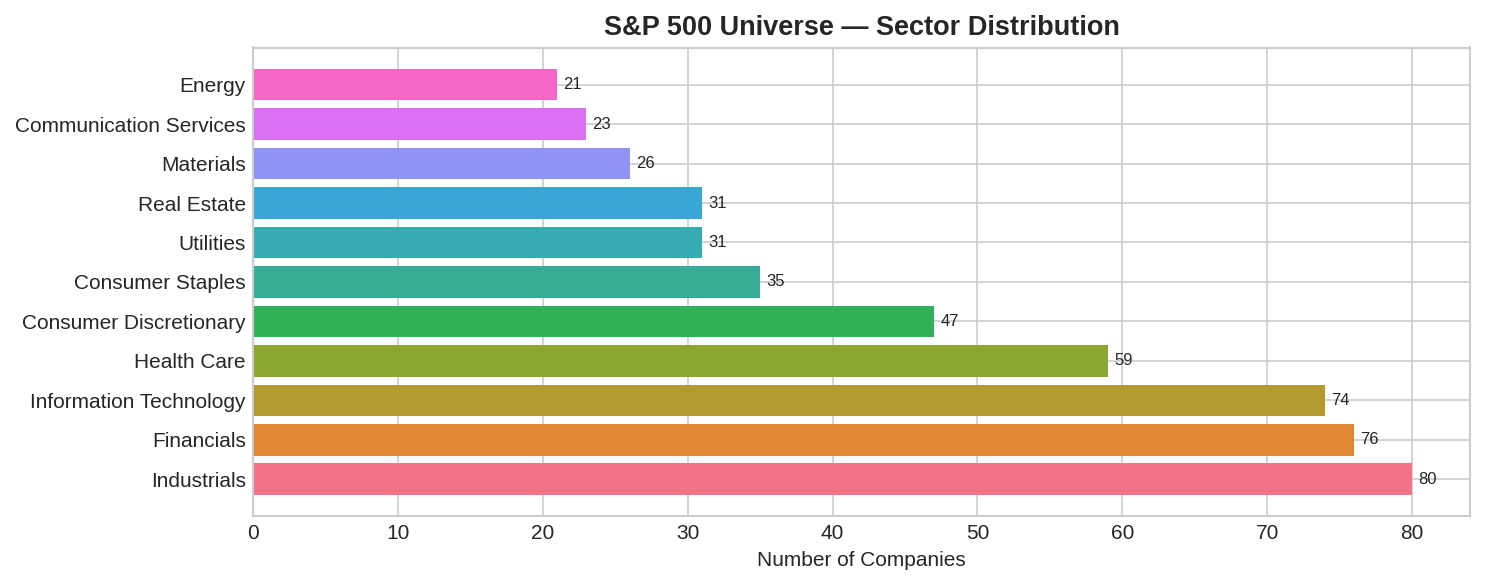


📊 Sector breakdown:
sector
Industrials               80
Financials                76
Information Technology    74
Health Care               59
Consumer Discretionary    47
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    21


In [25]:
# ── Sector distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4), dpi=PLOT_DPI)
sector_counts = universe_df['sector'].value_counts()
bars = ax.barh(sector_counts.index, sector_counts.values, color=sns.color_palette('husl', len(sector_counts)))
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel('Number of Companies')
ax.set_title('S&P 500 Universe — Sector Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sector_distribution.png', dpi=PLOT_DPI)
plt.show()
print(f'\n📊 Sector breakdown:\n{sector_counts.to_string()}')

---
# 📥 CELL 4 — Data Collection Pipeline

In [26]:
# ============================================================
# CELL 4: Data Collection Pipeline
#
# For each ticker we extract:
#   • Income statement: revenue, EBIT, EBITDA, net income, EPS
#   • Balance sheet: total assets, equity, total debt, cash
#   • Cash flow: operating CF, capex, free cash flow
#   • Quote / valuation: market cap, P/E, P/B, EV, enterprise metrics
#
# yfinance returns trailing twelve months (TTM) and annual data.
# We use annual statements for multi-year CAGR calculations.
# ============================================================

def safe_get(series: pd.Series, index: int = 0, default=np.nan):
    """Safely retrieve a value from a Series by positional index."""
    try:
        if series is None or len(series) == 0:
            return default
        val = series.iloc[index]
        return val if pd.notna(val) else default
    except Exception:
        return default


def compute_cagr(series: pd.Series, years: int = CAGR_YEARS) -> float:
    """
    Compute CAGR from a time-indexed annual Series (most recent first).
    Returns NaN if insufficient data or negative base value.
    """
    try:
        s = series.dropna()
        if len(s) < years + 1:
            return np.nan
        end_val   = s.iloc[0]             # most recent
        start_val = s.iloc[years]         # 'years' periods ago
        if start_val <= 0 or end_val <= 0:
            return np.nan
        return (end_val / start_val) ** (1 / years) - 1
    except Exception:
        return np.nan


def extract_ticker_data(ticker: str) -> dict:
    """
    Pull all fundamental data for a single ticker via yfinance.
    Returns a flat dictionary of raw metrics. Returns None on failure.
    """
    try:
        tk = yf.Ticker(ticker)
        info = tk.info or {}

        # ── Annual statements (columns = fiscal year dates) ──
        inc  = tk.financials          # income statement, most recent first
        bal  = tk.balance_sheet
        cf   = tk.cashflow

        # ── Helper to pull a row safely ──────────────────────
        def row(df, key):
            if df is None or df.empty or key not in df.index:
                return pd.Series(dtype=float)
            return df.loc[key]

        # ── Income Statement ─────────────────────────────────
        revenue_series  = row(inc, 'Total Revenue')
        ebit_series     = row(inc, 'EBIT')
        ni_series       = row(inc, 'Net Income')
        gross_series    = row(inc, 'Gross Profit')
        eps_series      = row(inc, 'Diluted EPS') if 'Diluted EPS' in (inc.index if inc is not None else []) else pd.Series(dtype=float)

        # ── Balance Sheet ────────────────────────────────────
        equity_series   = row(bal, 'Stockholders Equity')
        assets_series   = row(bal, 'Total Assets')
        debt_series     = row(bal, 'Total Debt')
        cash_series     = row(bal, 'Cash And Cash Equivalents')

        # ── Cash Flow ────────────────────────────────────────
        ocf_series      = row(cf, 'Operating Cash Flow')
        capex_series    = row(cf, 'Capital Expenditure')

        # ── Derived: Free Cash Flow ──────────────────────────
        # FCF = Operating CF - |CapEx|  (CapEx is typically negative in yfinance)
        fcf_series = ocf_series + capex_series.fillna(0)  # capex is negative

        # ── TTM / most-recent values ─────────────────────────
        revenue_ttm = safe_get(revenue_series)
        ebit_ttm    = safe_get(ebit_series)
        ni_ttm      = safe_get(ni_series)
        gross_ttm   = safe_get(gross_series)
        equity_ttm  = safe_get(equity_series)
        assets_ttm  = safe_get(assets_series)
        debt_ttm    = safe_get(debt_series, default=0)
        cash_ttm    = safe_get(cash_series, default=0)
        ocf_ttm     = safe_get(ocf_series)
        fcf_ttm     = safe_get(fcf_series)

        # ── Market / Valuation (from info dict) ──────────────
        mkt_cap     = info.get('marketCap',          np.nan)
        pe_ratio    = info.get('trailingPE',         np.nan)
        pb_ratio    = info.get('priceToBook',        np.nan)
        ev          = info.get('enterpriseValue',    np.nan)
        ev_ebitda   = info.get('enterpriseToEbitda', np.nan)
        shares      = info.get('sharesOutstanding',  np.nan)
        price       = info.get('currentPrice',       np.nan)

        # ── Derived Valuation Metrics ─────────────────────────
        # P/FCF: only valid when FCF > 0
        p_fcf = mkt_cap / fcf_ttm if (pd.notna(fcf_ttm) and fcf_ttm > 0 and pd.notna(mkt_cap)) else np.nan

        # EV/EBIT: alternative value metric
        ev_ebit = ev / ebit_ttm if (pd.notna(ev) and pd.notna(ebit_ttm) and ebit_ttm > 0) else np.nan

        # ── Quality Metrics ───────────────────────────────────
        roe  = ni_ttm / equity_ttm if (pd.notna(equity_ttm) and equity_ttm > 0 and pd.notna(ni_ttm)) else np.nan
        roa  = ni_ttm / assets_ttm if (pd.notna(assets_ttm) and assets_ttm > 0 and pd.notna(ni_ttm)) else np.nan

        # ROIC = EBIT*(1-tax_rate) / (equity + debt - cash)
        invested_cap = equity_ttm + debt_ttm - cash_ttm if pd.notna(equity_ttm) else np.nan
        tax_rate     = info.get('effectiveTaxRate', 0.21)
        roic = ebit_ttm * (1 - tax_rate) / invested_cap if (pd.notna(invested_cap) and invested_cap > 0 and pd.notna(ebit_ttm)) else np.nan

        gross_margin_ttm = gross_ttm / revenue_ttm if (pd.notna(revenue_ttm) and revenue_ttm > 0 and pd.notna(gross_ttm)) else np.nan
        debt_to_equity   = debt_ttm / equity_ttm if (pd.notna(equity_ttm) and equity_ttm > 0) else np.nan

        # ── Gross Margin Stability (std dev over 4 years) ─────
        gross_margins = gross_series / revenue_series
        gross_margin_stability = -gross_margins.std()  # negative: lower std = higher quality

        # ── Growth CAGRs ──────────────────────────────────────
        revenue_cagr = compute_cagr(revenue_series)
        fcf_cagr     = compute_cagr(fcf_series)

        # EPS CAGR: use diluted EPS from info if not in statements
        if len(eps_series.dropna()) >= CAGR_YEARS + 1:
            eps_cagr = compute_cagr(eps_series)
        else:
            # Approximate from net income / shares
            ni_cagr  = compute_cagr(ni_series)
            eps_cagr = ni_cagr  # proxy when EPS series unavailable

        return {
            'ticker':                 ticker,
            'market_cap':             mkt_cap,
            'price':                  price,
            # ── Value factors ────────────────────────────────
            'pe_ratio':               pe_ratio,
            'pb_ratio':               pb_ratio,
            'ev_ebitda':              ev_ebitda,
            'ev_ebit':                ev_ebit,
            'p_fcf':                  p_fcf,
            # ── Quality factors ──────────────────────────────
            'roe':                    roe,
            'roa':                    roa,
            'roic':                   roic,
            'gross_margin':           gross_margin_ttm,
            'gross_margin_stability': gross_margin_stability,
            'debt_to_equity':         debt_to_equity,
            # ── Growth factors ───────────────────────────────
            'revenue_cagr':           revenue_cagr,
            'eps_cagr':               eps_cagr,
            'fcf_cagr':               fcf_cagr,
            # ── Supplementary ────────────────────────────────
            'revenue_ttm':            revenue_ttm,
            'ebit_ttm':               ebit_ttm,
            'fcf_ttm':                fcf_ttm,
            'equity_ttm':             equity_ttm,
        }

    except Exception as e:
        # Silently skip failed tickers; log for diagnostics
        logging.warning(f'Failed to extract {ticker}: {e}')
        return None


print('✅ Data extraction functions defined.')

✅ Data extraction functions defined.


In [27]:
`# ============================================================
# CELL 4b: Run Data Collection (with progress bar + caching)
#
# NOTE: Pulling ~500 tickers takes 15-30 minutes due to
# Yahoo Finance rate limits. A checkpoint CSV is saved every
# BATCH_SIZE tickers so you can resume if interrupted.
# ============================================================

CHECKPOINT_PATH = OUTPUT_DIR / 'raw_data_checkpoint.csv'
tickers = universe_df['ticker'].tolist()

# ── Resume from checkpoint if it exists ──────────────────────
if CHECKPOINT_PATH.exists():
    existing = pd.read_csv(CHECKPOINT_PATH)
    done_tickers = set(existing['ticker'].tolist())
    raw_records  = existing.to_dict('records')
    remaining    = [t for t in tickers if t not in done_tickers]
    print(f'🔄 Resuming from checkpoint: {len(done_tickers)} done, {len(remaining)} remaining.')
else:
    raw_records = []
    remaining   = tickers
    print(f'🚀 Starting fresh collection for {len(remaining)} tickers.')

failed_tickers = []

for i, ticker in enumerate(tqdm(remaining, desc='Fetching fundamentals')):
    result = extract_ticker_data(ticker)
    if result:
        raw_records.append(result)
    else:
        failed_tickers.append(ticker)

    time.sleep(REQUEST_DELAY)

    # Save checkpoint every BATCH_SIZE tickers
    if (i + 1) % BATCH_SIZE == 0:
        pd.DataFrame(raw_records).to_csv(CHECKPOINT_PATH, index=False)
        print(f'  💾 Checkpoint saved ({len(raw_records)} records)')

# ── Save final checkpoint ─────────────────────────────────────
raw_df = pd.DataFrame(raw_records)
raw_df.to_csv(CHECKPOINT_PATH, index=False)

print(f'\n✅ Collection complete!')
print(f'   Successful: {len(raw_df)} | Failed: {len(failed_tickers)}')
if failed_tickers:
    print(f'   Failed tickers: {failed_tickers[:20]}...')
raw_df.head()

SyntaxError: invalid syntax (2296128793.py, line 1)

---
# 🔧 CELL 5 — Data Cleaning & Feature Engineering

In [28]:
# ============================================================
# CELL 5: Data Cleaning & Feature Engineering
#
# Steps:
#   1. Merge fundamental data with sector metadata
#   2. Clip extreme outliers (Winsorize at 1st/99th percentile)
#   3. Fill remaining NaN with sector-median imputation
#   4. Flag data quality issues
#   5. Add derived features used in scoring
# ============================================================

def winsorize_col(series: pd.Series, lower=0.01, upper=0.99) -> pd.Series:
    """
    Clip values to the [lower, upper] quantile range to reduce outlier impact.
    Operates only on non-NaN values.
    """
    q_low  = series.quantile(lower)
    q_high = series.quantile(upper)
    return series.clip(q_low, q_high)


def sector_median_fill(df: pd.DataFrame, col: str) -> pd.Series:
    """Fill NaN values in a column with the sector-level median."""
    return df.groupby('sector')[col].transform(lambda x: x.fillna(x.median()))


# ── 1. Merge with sector labels ──────────────────────────────
df = raw_df.merge(universe_df[['ticker', 'company', 'sector', 'sub_industry']],
                  on='ticker', how='left')

print(f'Merged shape: {df.shape}')

# ── 2. Define factor columns ──────────────────────────────────
# For value factors: lower is cheaper → we invert sign when scoring
VALUE_COLS   = ['pe_ratio', 'pb_ratio', 'ev_ebitda', 'p_fcf']
QUALITY_COLS = ['roe', 'roic', 'gross_margin', 'gross_margin_stability']
GROWTH_COLS  = ['revenue_cagr', 'eps_cagr', 'fcf_cagr']
ALL_FACTOR_COLS = VALUE_COLS + QUALITY_COLS + GROWTH_COLS

# ── 3. Remove clearly invalid records ────────────────────────
# Filter: must have market cap > $500M and at least one valid metric per pillar
df = df[df['market_cap'].fillna(0) > 5e8].copy()

# ── 4. Winsorize each factor column ──────────────────────────
for col in ALL_FACTOR_COLS:
    if col in df.columns:
        df[col] = winsorize_col(df[col])

# ── 5. Sector-median imputation ───────────────────────────────
# Prefer sector context over global median for more relevant fills
for col in ALL_FACTOR_COLS:
    if col in df.columns:
        df[col] = sector_median_fill(df, col)
        # If still NaN (entire sector missing), fill with global median
        df[col] = df[col].fillna(df[col].median())

# ── 6. Debt-to-equity cleanup (NaN → 0 for no-debt companies) ─
df['debt_to_equity'] = df['debt_to_equity'].fillna(0)

# ── 7. Data quality flag ──────────────────────────────────────
df['missing_pct'] = df[ALL_FACTOR_COLS].isna().mean(axis=1)

print(f'\n✅ Cleaning complete.')
print(f'   Final universe: {len(df)} stocks')
print(f'   Avg missing pct (post-imputation): {df["missing_pct"].mean():.1%}')
print(f'\nColumn nulls remaining:')
print(df[ALL_FACTOR_COLS].isna().sum())

Merged shape: (503, 24)

✅ Cleaning complete.
   Final universe: 503 stocks
   Avg missing pct (post-imputation): 0.0%

Column nulls remaining:
pe_ratio                  0
pb_ratio                  0
ev_ebitda                 0
p_fcf                     0
roe                       0
roic                      0
gross_margin              0
gross_margin_stability    0
revenue_cagr              0
eps_cagr                  0
fcf_cagr                  0
dtype: int64


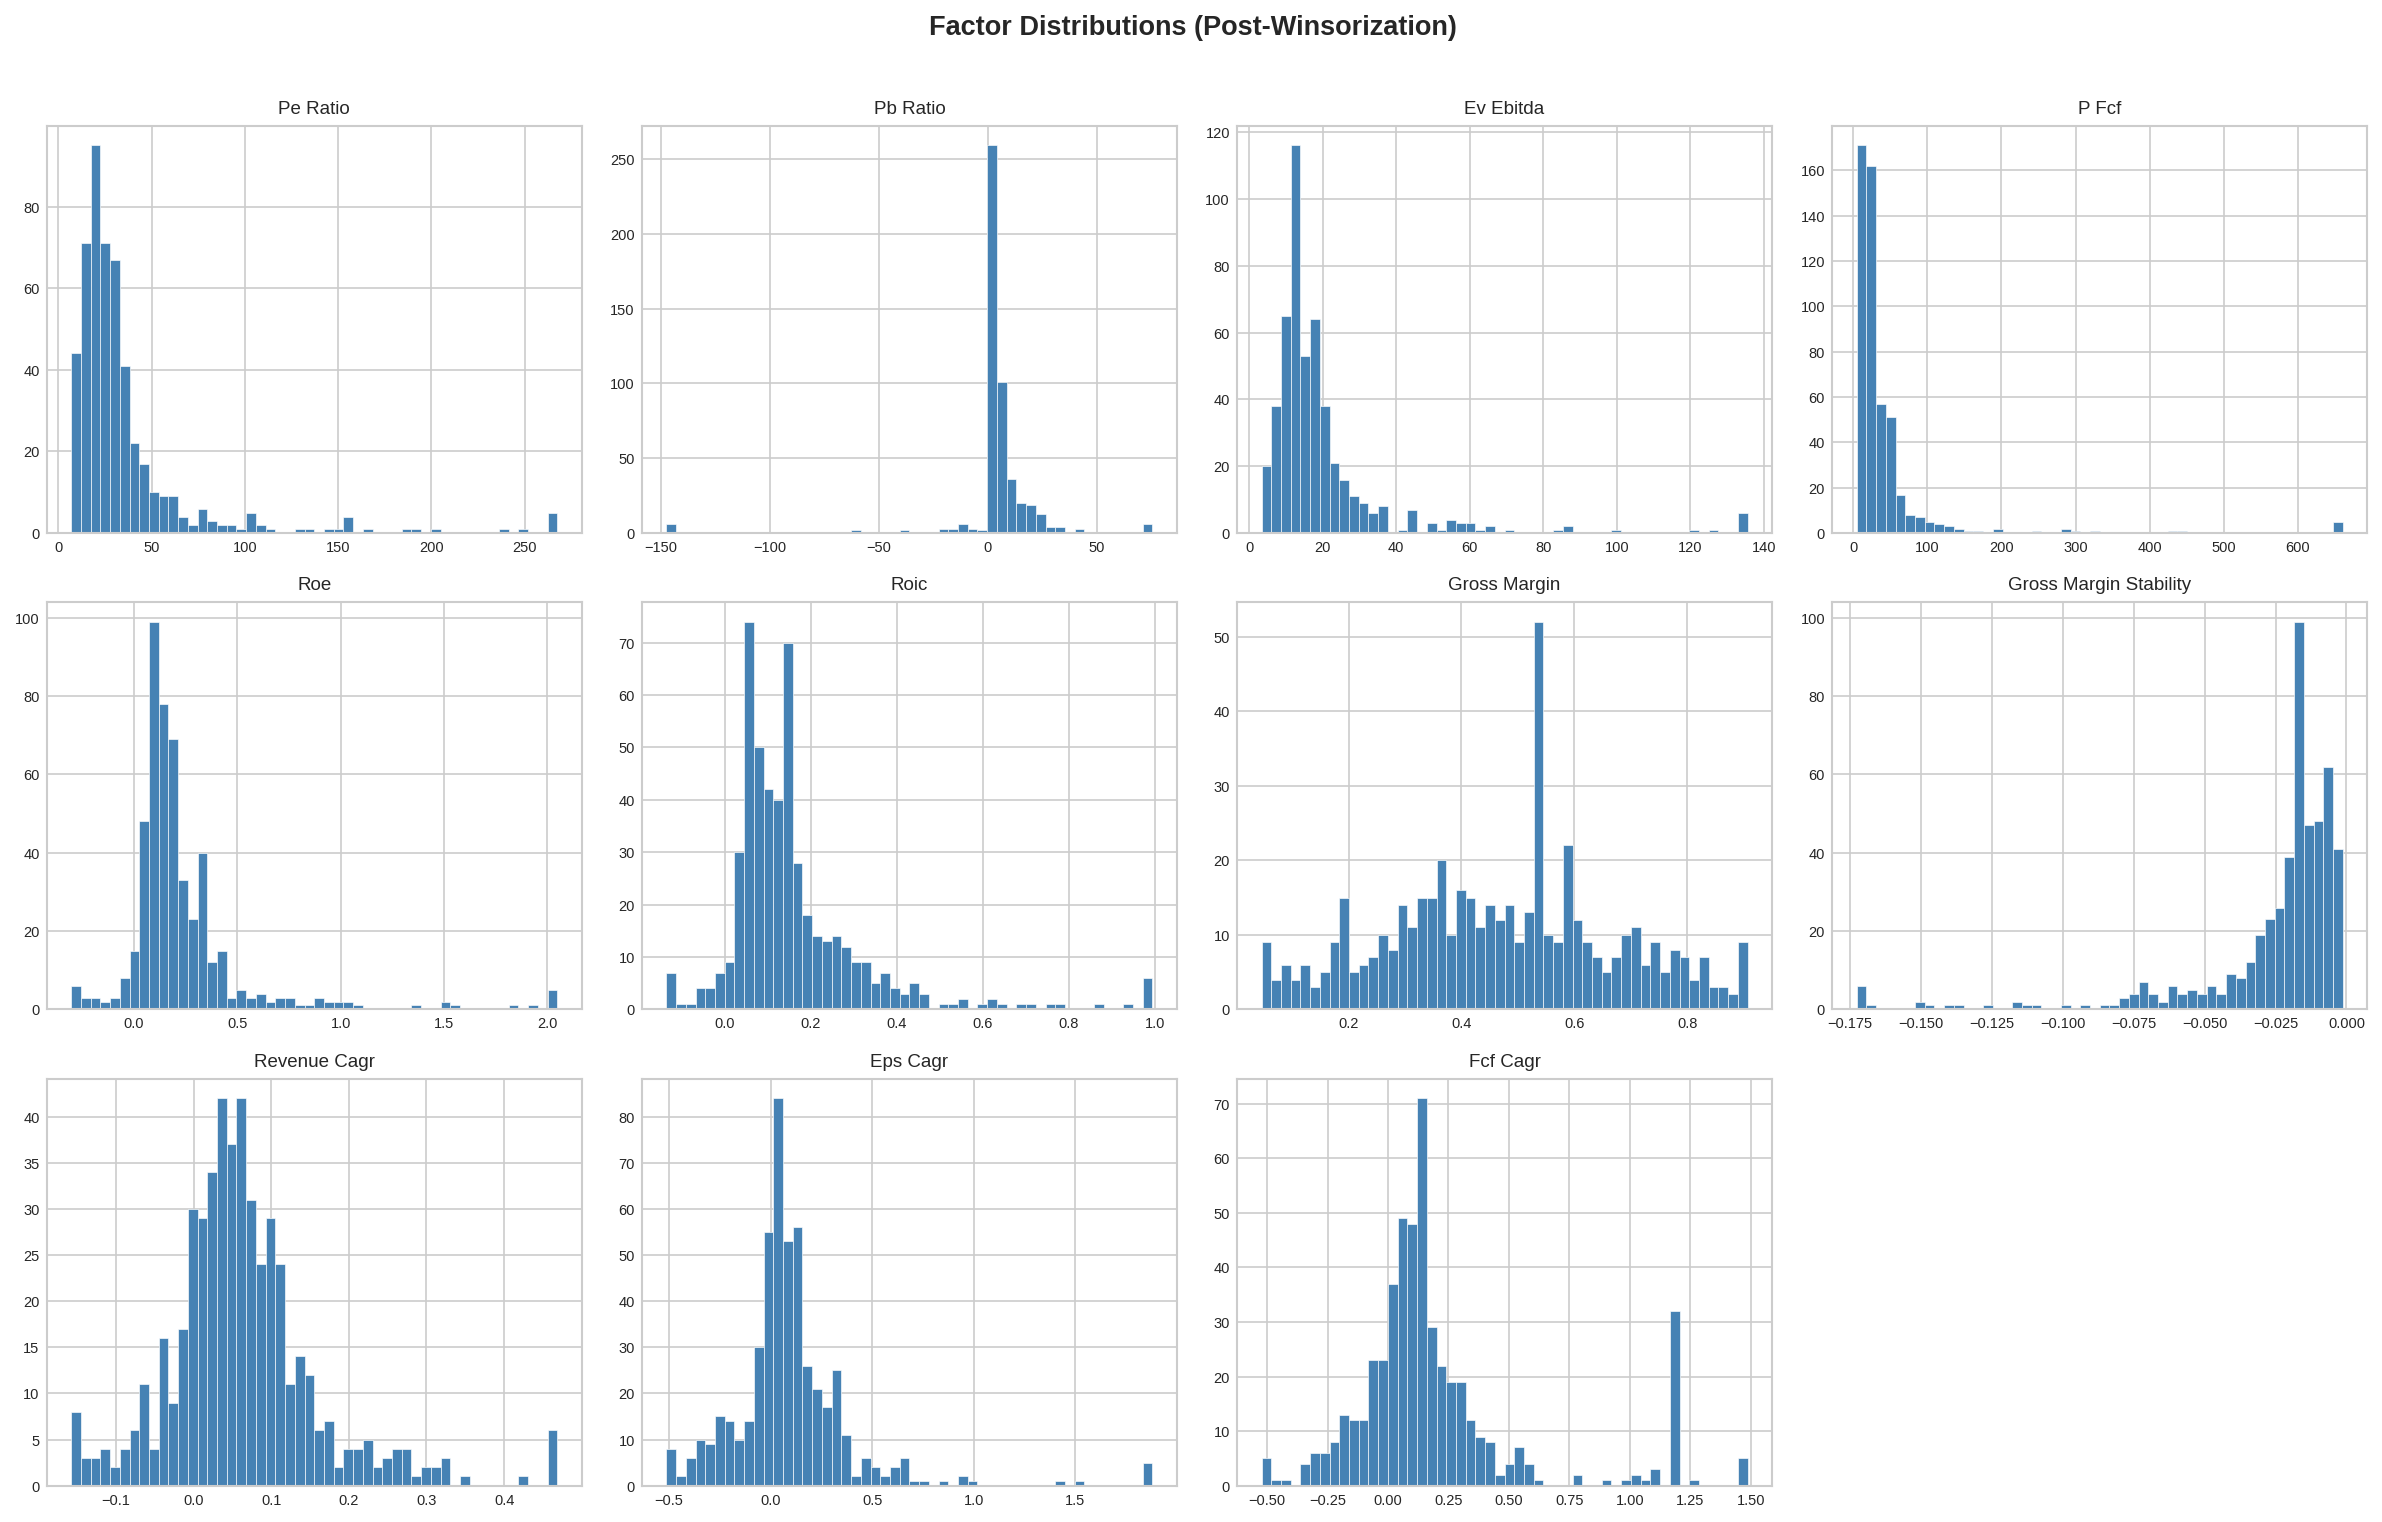

In [29]:
# ── Distribution plot: check factor distributions post-cleaning ─
fig, axes = plt.subplots(3, 4, figsize=(16, 10), dpi=PLOT_DPI)
axes = axes.flatten()

plot_cols = [c for c in ALL_FACTOR_COLS if c in df.columns]
for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Factor Distributions (Post-Winsorization)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'factor_distributions.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

---
# 🧮 CELL 6 — Factor Scoring Engine (Z-Score Normalization)

In [30]:
# ============================================================
# CELL 6: Factor Scoring Engine
#
# Methodology:
#   1. Cross-sectional Z-score each raw metric
#   2. For value metrics: invert sign (lower P/E = better score)
#   3. For debt-to-equity: invert sign (lower leverage = better)
#   4. Average Z-scores within each pillar
#   5. Weighted sum to produce composite score
#   6. Percentile-rank the composite (0-100 scale)
# ============================================================

def zscore_col(series: pd.Series) -> pd.Series:
    """Cross-sectional Z-score (mean=0, std=1)."""
    return (series - series.mean()) / series.std(ddof=1)


def to_percentile(series: pd.Series) -> pd.Series:
    """Convert raw scores to percentile rank (0-100)."""
    return series.rank(pct=True) * 100


scored = df.copy()

# ── VALUE PILLAR ─────────────────────────────────────────────
# Lower valuation multiples = better → negate Z-scores
for col in VALUE_COLS:
    scored[f'z_{col}'] = -zscore_col(scored[col])  # inverted

scored['value_score'] = scored[[f'z_{c}' for c in VALUE_COLS]].mean(axis=1)

# ── QUALITY PILLAR ────────────────────────────────────────────
# Higher ROE/ROIC/margins = better (positive direction)
# debt_to_equity: lower = better → invert
for col in QUALITY_COLS:
    scored[f'z_{col}'] = zscore_col(scored[col])

# Debt penalty (lower D/E → better quality)
scored['z_debt_penalty'] = -zscore_col(scored['debt_to_equity'])

quality_z_cols = [f'z_{c}' for c in QUALITY_COLS] + ['z_debt_penalty']
scored['quality_score'] = scored[quality_z_cols].mean(axis=1)

# ── GROWTH PILLAR ─────────────────────────────────────────────
# Higher CAGR = better (positive direction)
for col in GROWTH_COLS:
    scored[f'z_{col}'] = zscore_col(scored[col])

scored['growth_score'] = scored[[f'z_{c}' for c in GROWTH_COLS]].mean(axis=1)

# ── COMPOSITE SCORE ───────────────────────────────────────────
scored['composite_score_raw'] = (
    FACTOR_WEIGHTS['value']   * scored['value_score'] +
    FACTOR_WEIGHTS['quality'] * scored['quality_score'] +
    FACTOR_WEIGHTS['growth']  * scored['growth_score']
)

# Convert to 0-100 percentile within the universe
scored['composite_score']    = to_percentile(scored['composite_score_raw'])
scored['value_pct']          = to_percentile(scored['value_score'])
scored['quality_pct']        = to_percentile(scored['quality_score'])
scored['growth_pct']         = to_percentile(scored['growth_score'])

# ── Sort by composite score (descending) ──────────────────────
ranked = scored.sort_values('composite_score', ascending=False).reset_index(drop=True)
ranked['rank'] = ranked.index + 1

print('✅ Scoring complete.')
print(f'\nTop 10 stocks by composite score:')
cols_display = ['rank', 'ticker', 'company', 'sector',
                'composite_score', 'value_pct', 'quality_pct', 'growth_pct']
ranked[cols_display].head(10)

✅ Scoring complete.

Top 10 stocks by composite score:


,rank,ticker,company,sector,composite_score,value_pct,quality_pct,growth_pct
0,1,NVDA,Nvidia,Information Technology,100.00,13.52,95.83,100.00
1,2,DELL,Dell Technologies,Information Technology,99.80,99.20,61.23,96.62
2,3,PGR,Progressive Corporation,Financials,99.60,90.85,86.88,99.40
3,4,IBKR,Interactive Brokers,Financials,99.40,45.33,98.81,97.42
4,5,CRM,Salesforce,Information Technology,99.20,75.94,76.14,99.01
5,6,PODD,Insulet Corporation,Health Care,99.01,36.38,65.21,99.80
6,7,CLX,Clorox,Consumer Staples,98.81,99.80,96.82,14.12
7,8,TTD,Trade Desk (The),Communication Services,98.61,74.35,86.68,97.22
8,9,INCY,Incyte,Health Care,98.41,77.53,97.61,89.07
9,10,MCD,McDonald's,Consumer Discretionary,98.21,99.60,83.70,47.32


---
# 📊 CELL 7 — Visualizations & Dashboard

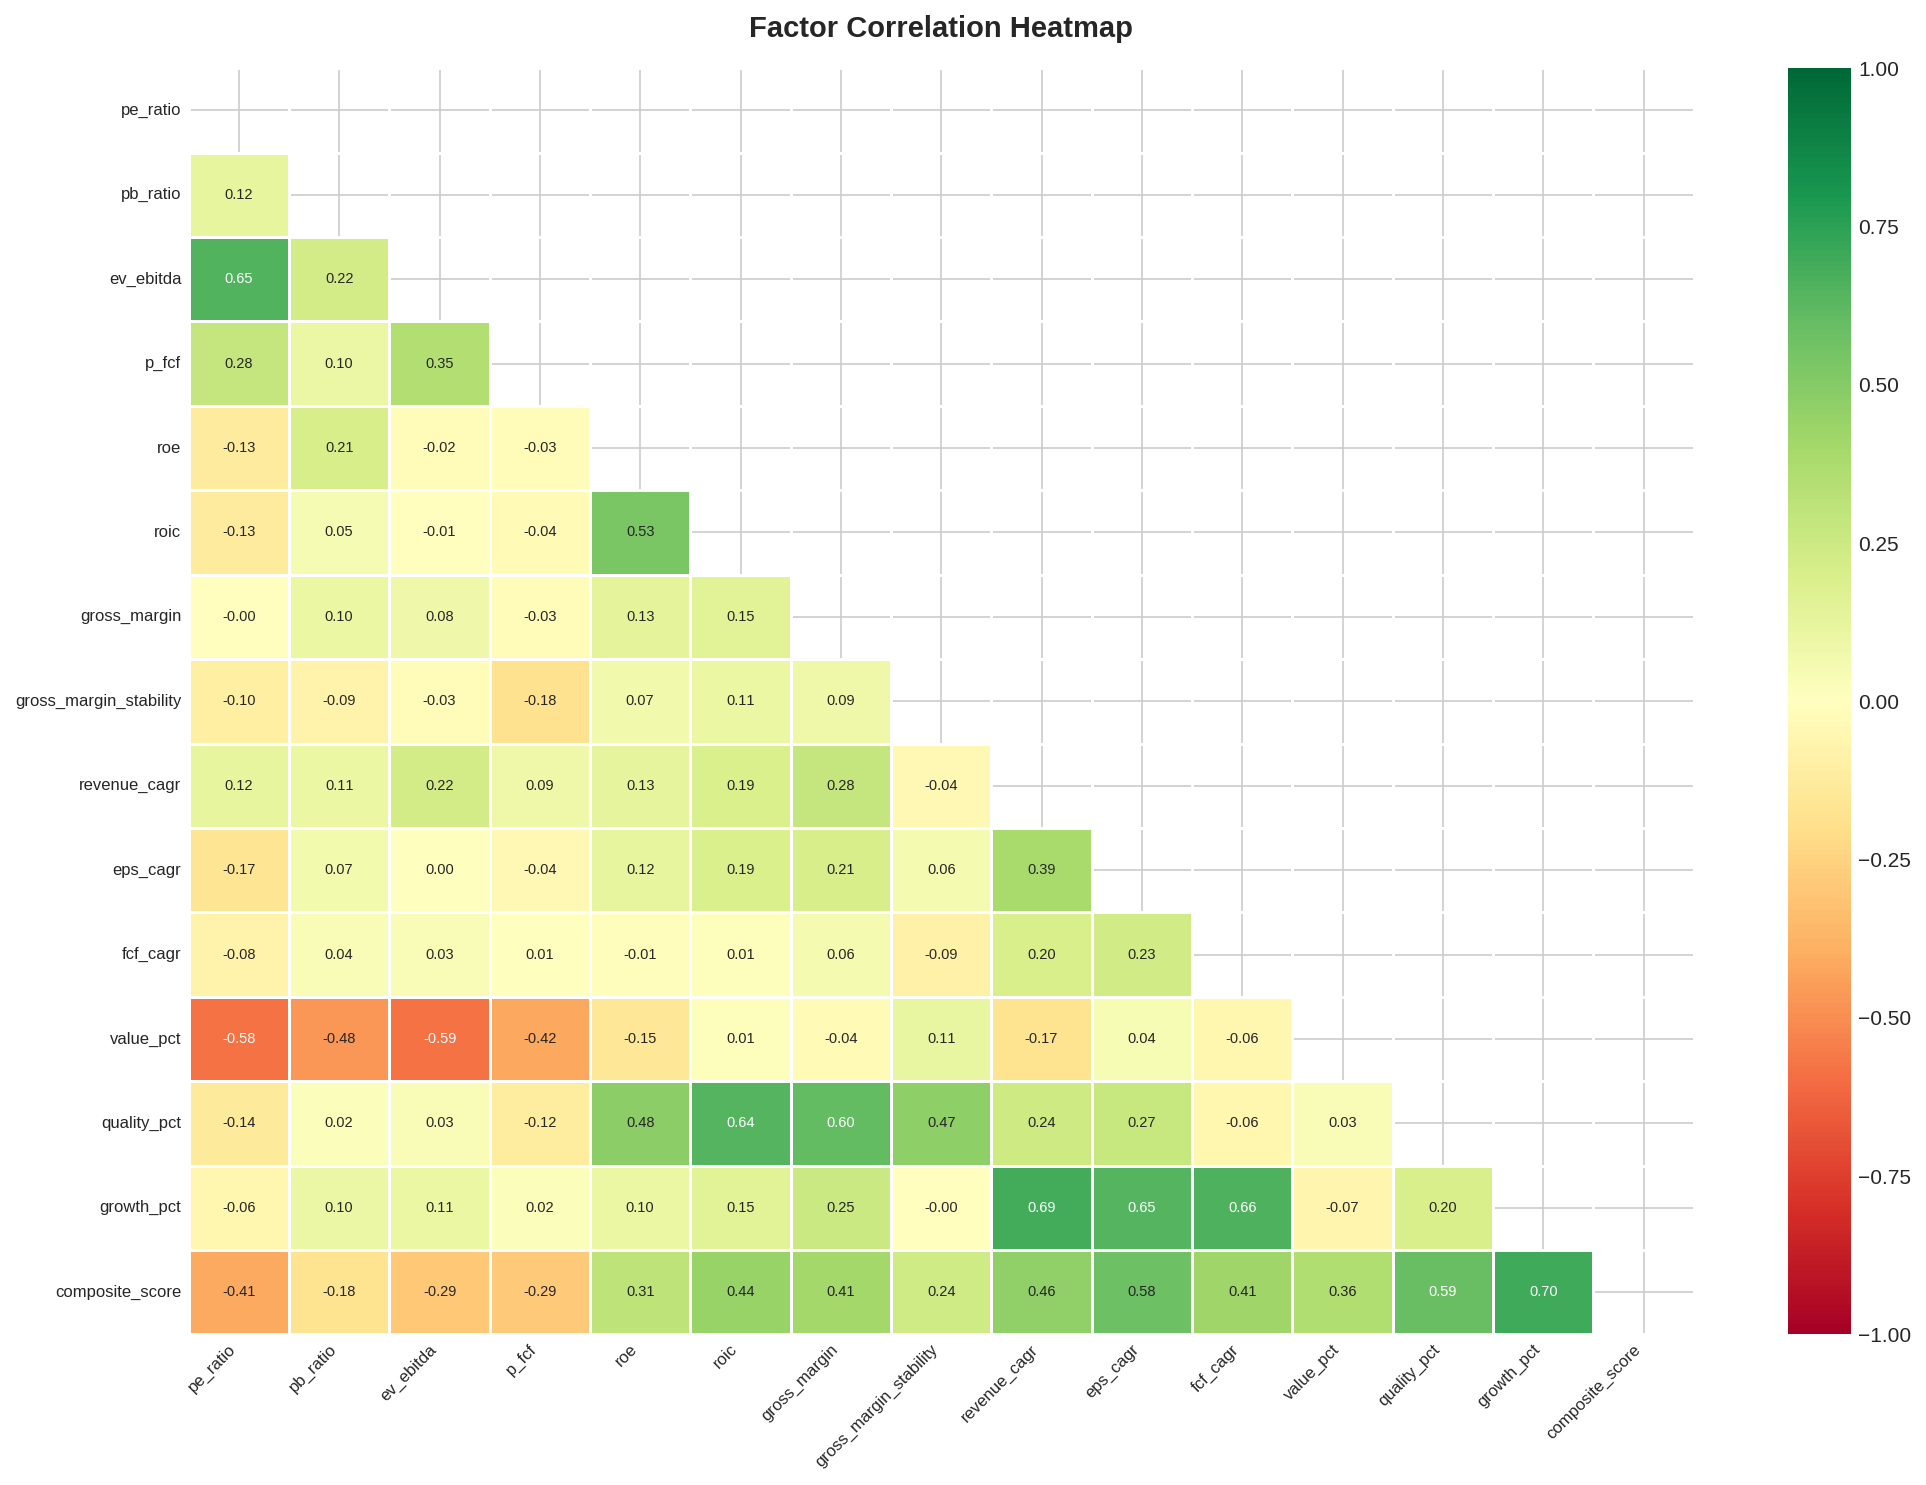

In [31]:
# ============================================================
# CELL 7a: Factor Correlation Heatmap
# Shows how value, quality, and growth signals relate to each other
# ============================================================

score_cols = ['value_pct', 'quality_pct', 'growth_pct', 'composite_score']
corr_cols  = ALL_FACTOR_COLS + score_cols
corr_matrix = ranked[[c for c in corr_cols if c in ranked.columns]].corr()

fig, ax = plt.subplots(figsize=(14, 10), dpi=PLOT_DPI)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7},
    vmin=-1, vmax=1,
)
ax.set_title('Factor Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'factor_correlation.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

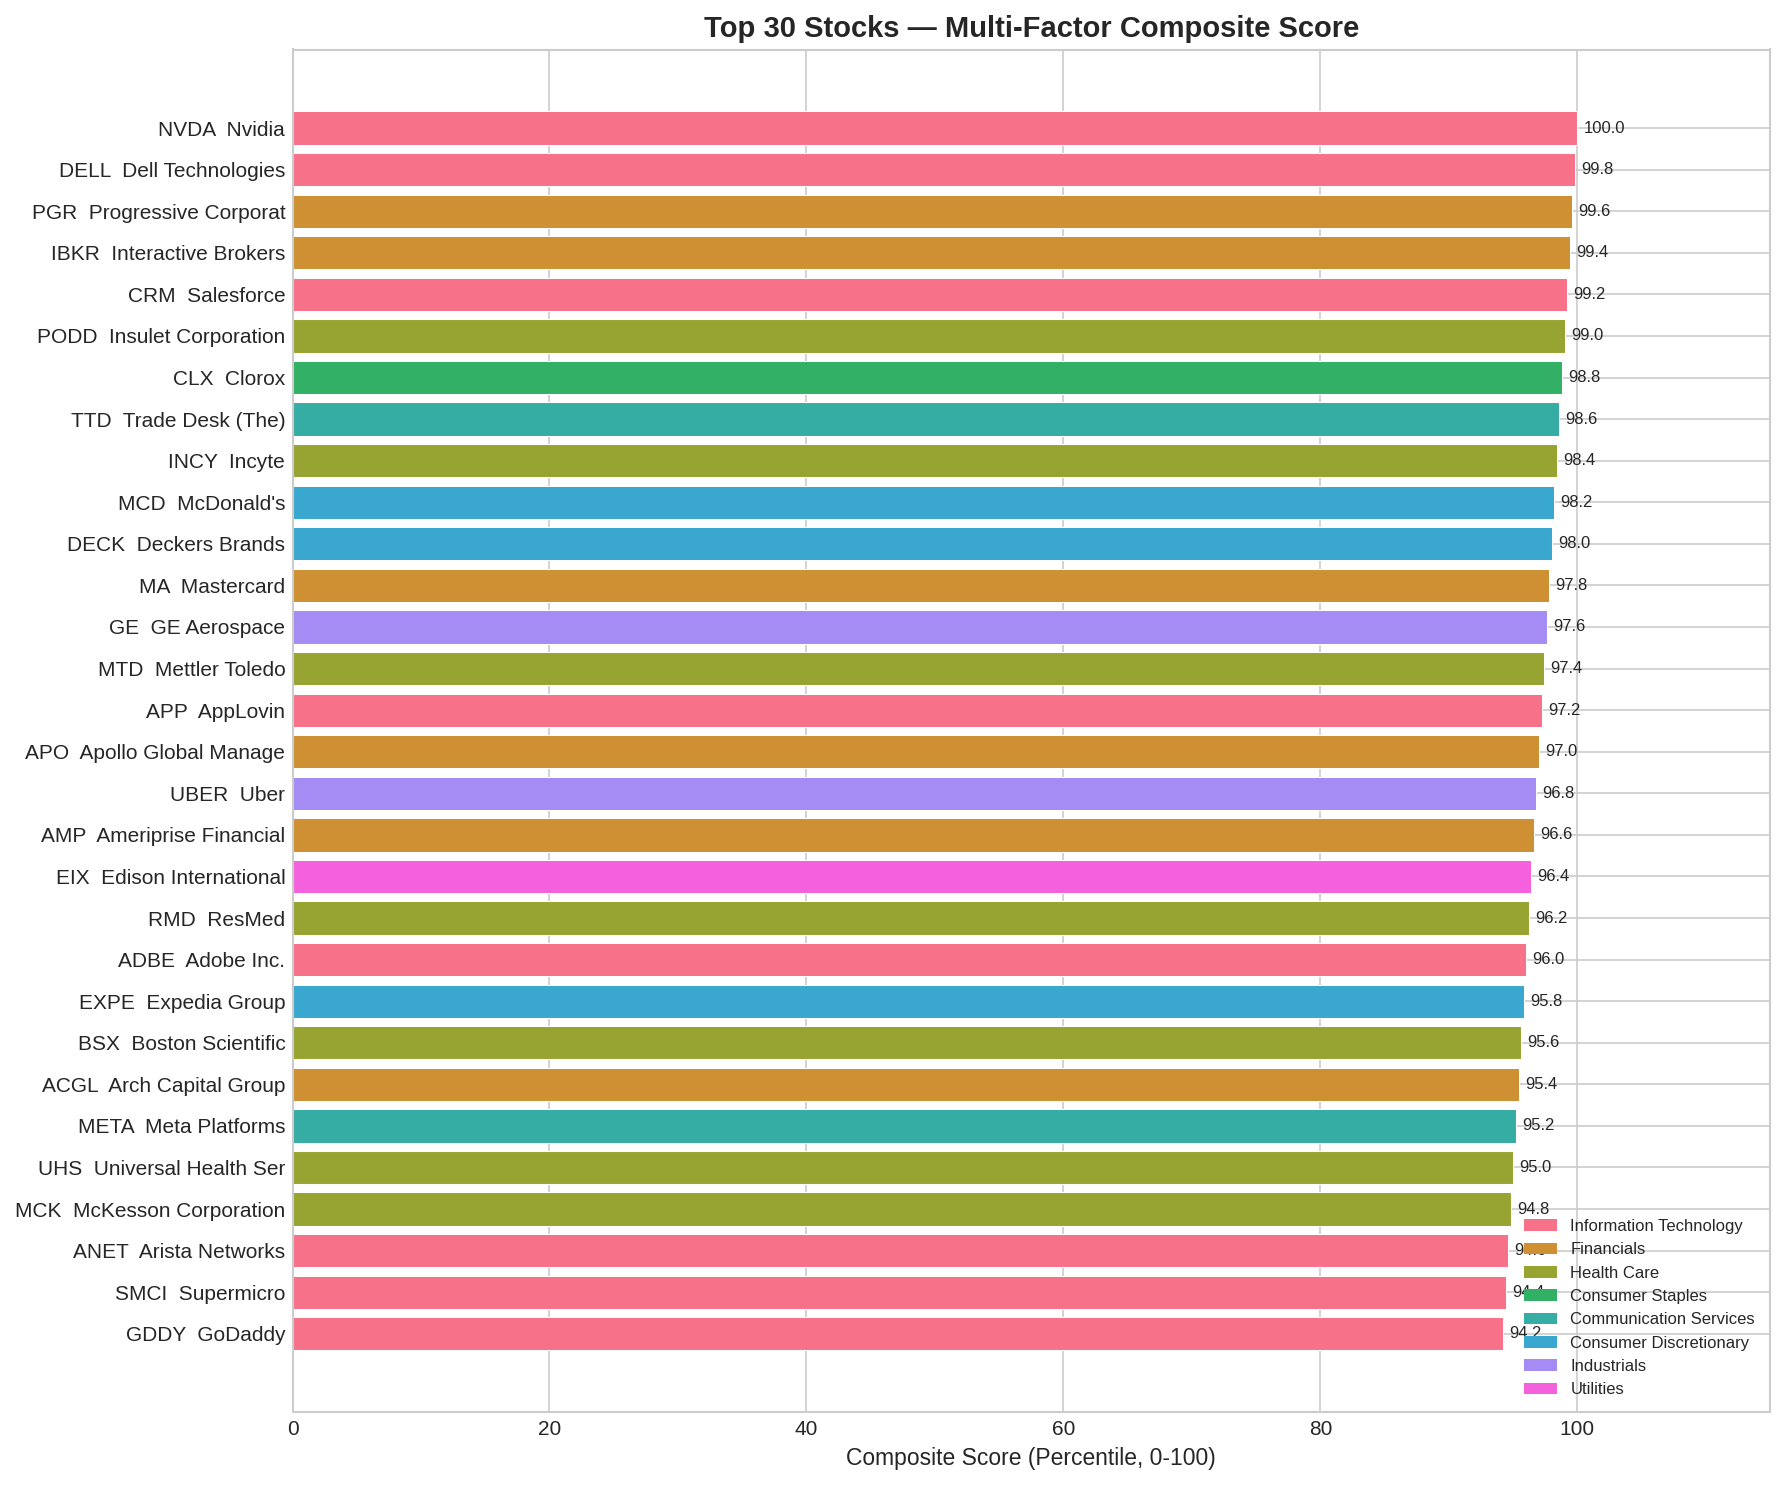

In [32]:
# ============================================================
# CELL 7b: Top 30 Stocks — Horizontal Bar Chart
# ============================================================

top30 = ranked.head(30).copy()

fig, ax = plt.subplots(figsize=(12, 10), dpi=PLOT_DPI)

# Color bars by sector
unique_sectors = top30['sector'].unique()
sector_colors  = dict(zip(unique_sectors, sns.color_palette('husl', len(unique_sectors))))
colors = [sector_colors[s] for s in top30['sector']]

bars = ax.barh(top30['ticker'] + '  ' + top30['company'].str[:20],
               top30['composite_score'],
               color=colors, edgecolor='white', linewidth=0.5)

ax.bar_label(bars, fmt='{:.1f}', padding=3, fontsize=8)
ax.set_xlabel('Composite Score (Percentile, 0-100)', fontsize=11)
ax.set_title('Top 30 Stocks — Multi-Factor Composite Score', fontsize=14, fontweight='bold')
ax.set_xlim(0, 115)
ax.invert_yaxis()

# Legend for sectors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in sector_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top30_composite_score.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

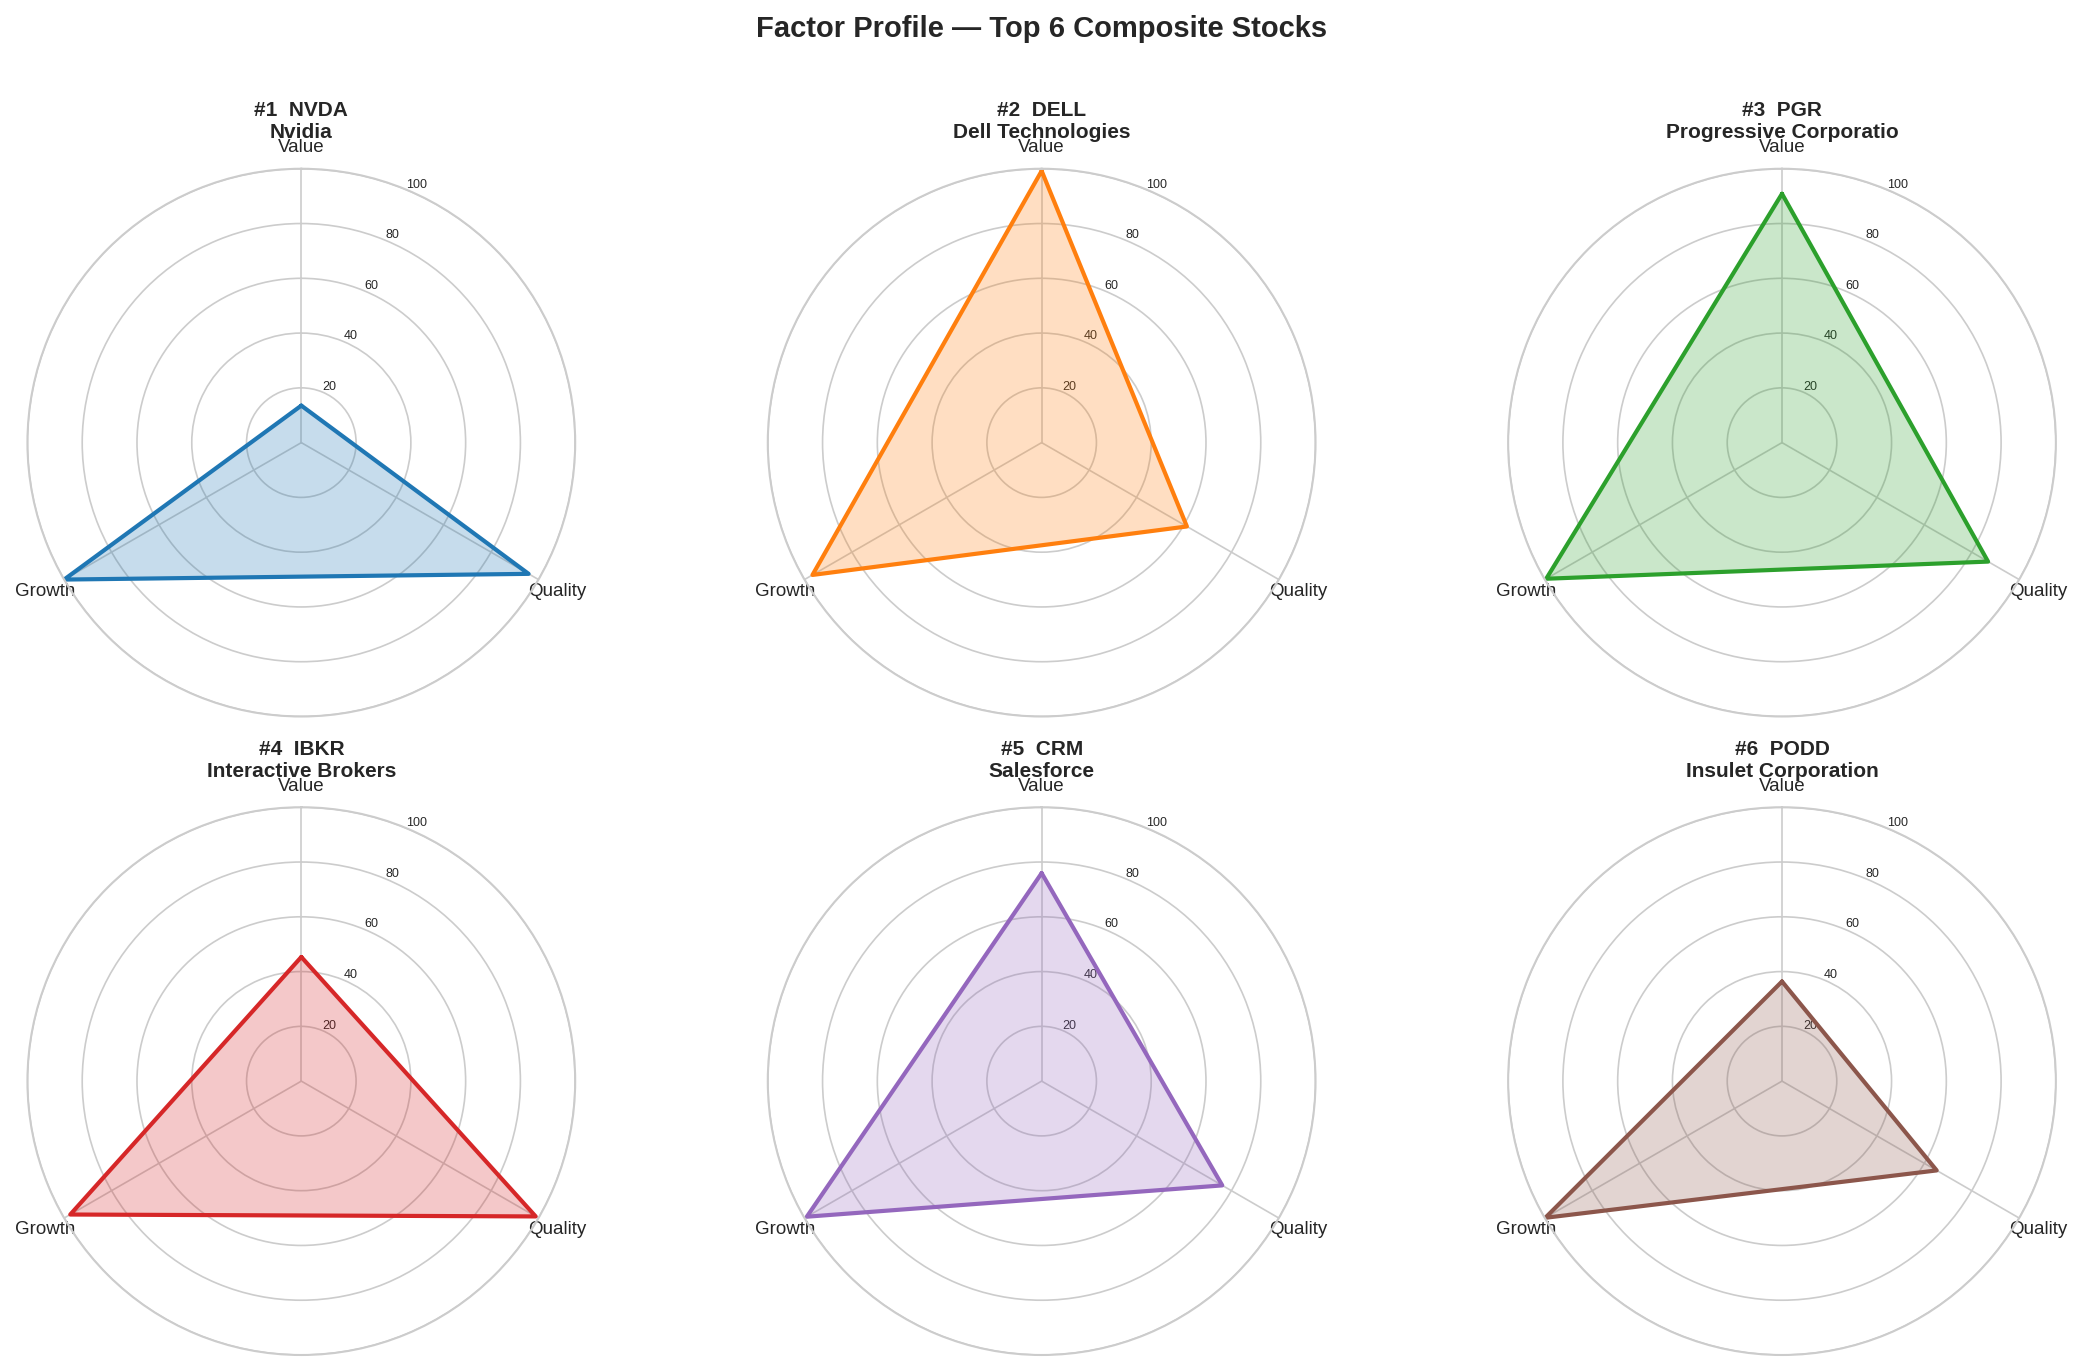

In [33]:
# ============================================================
# CELL 7c: Spider / Radar Charts — Top 6 Stocks
# Shows each stock's Value / Quality / Growth profile
# ============================================================

def radar_chart(ax, values, labels, title, color):
    """Draw a single radar chart on the given axes."""
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values_plot = values + values[:1]
    angles_plot = angles + angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.plot(angles_plot, values_plot, color=color, linewidth=2)
    ax.fill(angles_plot, values_plot, color=color, alpha=0.25)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=6)
    ax.set_title(title, size=10, fontweight='bold', pad=15)


top6 = ranked.head(6)
radar_labels = ['Value', 'Quality', 'Growth']
palette = sns.color_palette('tab10', 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), dpi=PLOT_DPI,
                          subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (_, row) in enumerate(top6.iterrows()):
    vals = [row['value_pct'], row['quality_pct'], row['growth_pct']]
    title = f"#{row['rank']}  {row['ticker']}\n{row['company'][:22]}"
    radar_chart(axes[i], vals, radar_labels, title, palette[i])

fig.suptitle('Factor Profile — Top 6 Composite Stocks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'radar_top6.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

In [34]:
# ============================================================
# CELL 7d: Value vs Quality Scatter — Bubble = Market Cap
# ============================================================

plot_df = ranked.head(100).copy()
plot_df['mkt_cap_bn'] = plot_df['market_cap'] / 1e9

fig = px.scatter(
    plot_df,
    x='value_pct',
    y='quality_pct',
    size='mkt_cap_bn',
    color='sector',
    hover_name='ticker',
    hover_data={
        'company': True,
        'composite_score': ':.1f',
        'growth_pct': ':.1f',
        'pe_ratio': ':.1f',
        'roe': ':.1%',
        'revenue_cagr': ':.1%',
        'mkt_cap_bn': ':.1f',
    },
    title='Value Score vs Quality Score — Top 100 Stocks (bubble = market cap)',
    labels={'value_pct': 'Value Percentile', 'quality_pct': 'Quality Percentile'},
    size_max=40,
    height=600,
    template='plotly_white',
)
fig.add_vline(x=50, line_dash='dash', line_color='gray', opacity=0.5)
fig.add_hline(y=50, line_dash='dash', line_color='gray', opacity=0.5)

# Annotate quadrants
for (x, y, txt) in [(75, 75, '🏆 GARP'), (25, 75, '💎 Quality Traps'),
                     (75, 25, '🔻 Value Traps'), (25, 25, '⚠️ Avoid')]:
    fig.add_annotation(x=x, y=y, text=txt, showarrow=False,
                        font=dict(size=11, color='gray'), opacity=0.6)

fig.write_html(str(OUTPUT_DIR / 'scatter_value_quality.html'))
fig.show()
print('📄 Interactive chart saved to screener_output/scatter_value_quality.html')

📄 Interactive chart saved to screener_output/scatter_value_quality.html


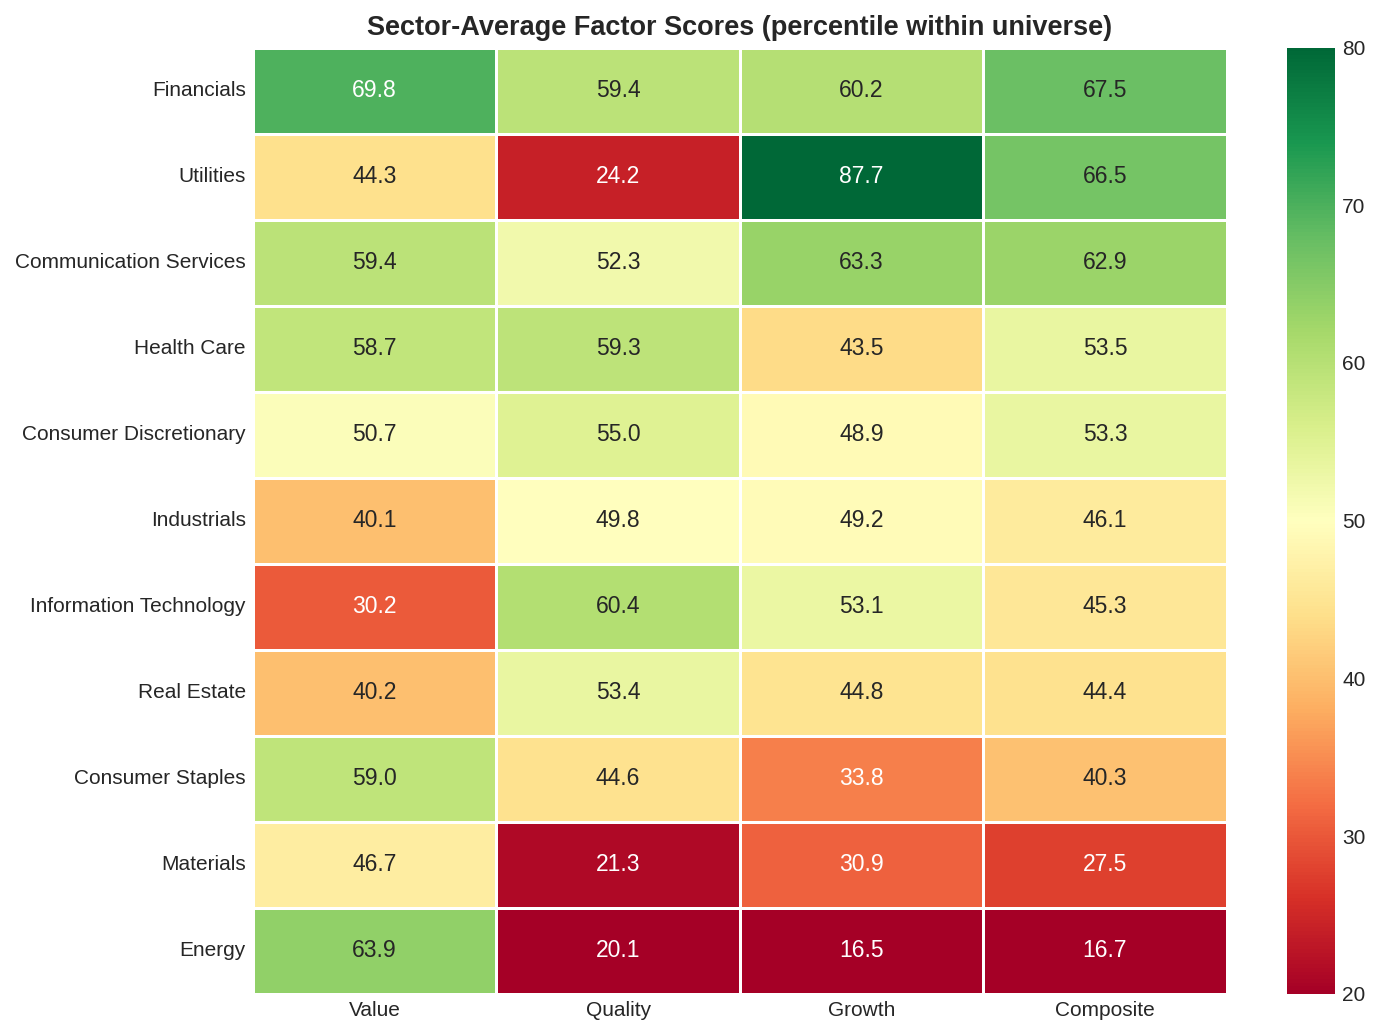

In [35]:
# ============================================================
# CELL 7e: Sector-Level Factor Heatmap
# Average factor scores per GICS sector — shows sector biases
# ============================================================

sector_avg = (
    ranked.groupby('sector')[['value_pct', 'quality_pct', 'growth_pct', 'composite_score']]
    .mean()
    .sort_values('composite_score', ascending=False)
)
sector_avg.columns = ['Value', 'Quality', 'Growth', 'Composite']

fig, ax = plt.subplots(figsize=(10, 7), dpi=PLOT_DPI)
sns.heatmap(
    sector_avg,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=20, vmax=80,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 11},
)
ax.set_title('Sector-Average Factor Scores (percentile within universe)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sector_factor_heatmap.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

In [36]:
# ============================================================
# CELL 7f: Interactive Composite Score Distribution
# ============================================================

fig = px.histogram(
    ranked,
    x='composite_score',
    color='sector',
    nbins=40,
    title='Distribution of Composite Scores — Full Universe',
    labels={'composite_score': 'Composite Score (Percentile)'},
    opacity=0.8,
    height=450,
    template='plotly_white',
)
fig.add_vline(
    x=ranked.head(TOP_N)['composite_score'].min(),
    line_dash='dash', line_color='red',
    annotation_text=f'Top {TOP_N} cutoff',
    annotation_position='top right',
)
fig.write_html(str(OUTPUT_DIR / 'score_distribution.html'))
fig.show()

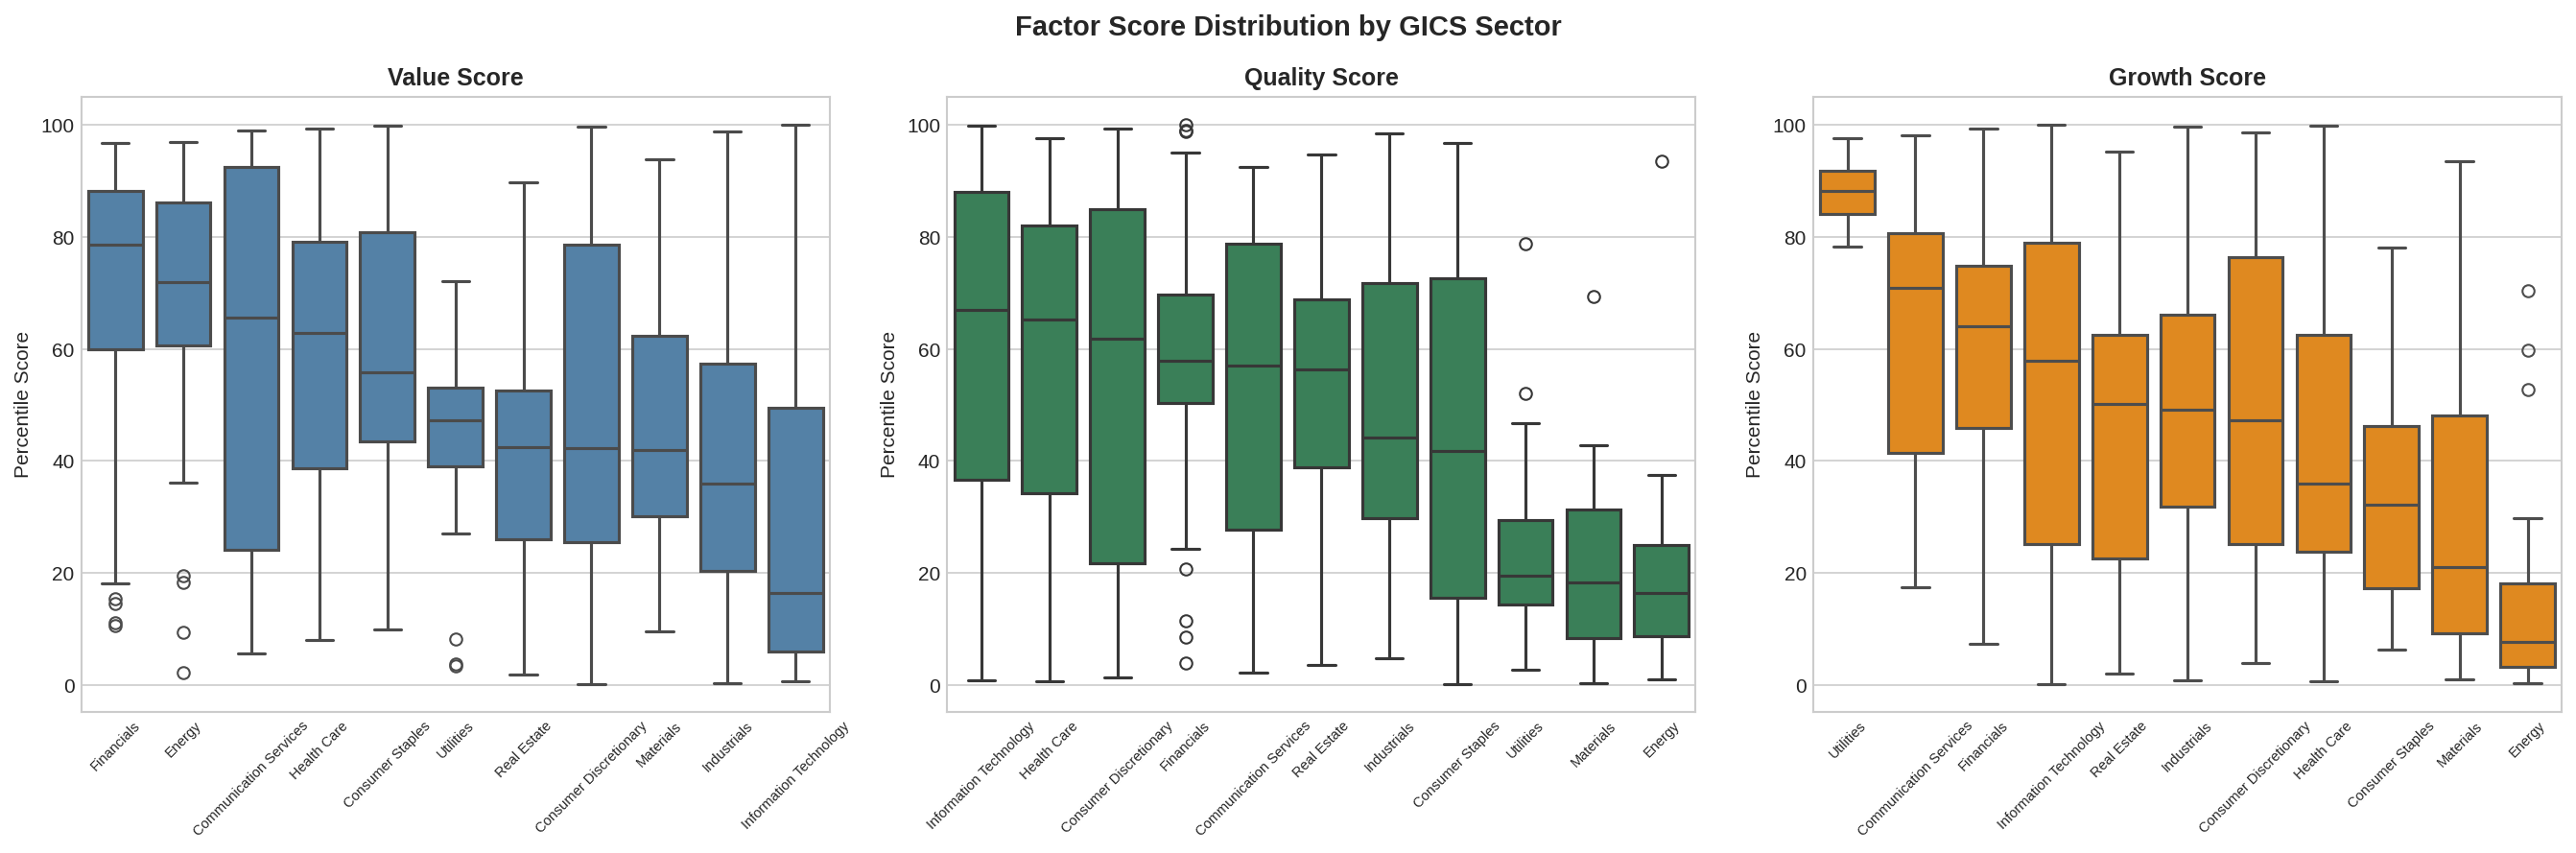

In [37]:
# ============================================================
# CELL 7g: Factor Pillar Score Distribution by Sector (FIXED)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=PLOT_DPI)
pillars = [
    ('value_pct',   'Value Score',   'steelblue'),
    ('quality_pct', 'Quality Score', 'seagreen'),
    ('growth_pct',  'Growth Score',  'darkorange'),
]

for ax, (col, title, color) in zip(axes, pillars):
    order = ranked.groupby('sector')[col].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(
        data=ranked,
        x='sector',
        y=col,
        order=order,
        ax=ax,
        color=color,
        linewidth=1.5,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentile Score')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Factor Score Distribution by GICS Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pillar_distribution_by_sector.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

---
# 🏆 CELL 8 — Final Ranked Watchlist

In [38]:
# ============================================================
# CELL 8: Build & Display the Final Ranked Watchlist
# ============================================================

watchlist_cols = [
    'rank', 'ticker', 'company', 'sector',
    # Composite & pillar scores
    'composite_score', 'value_pct', 'quality_pct', 'growth_pct',
    # Raw value metrics
    'pe_ratio', 'pb_ratio', 'ev_ebitda', 'p_fcf',
    # Raw quality metrics
    'roe', 'roic', 'gross_margin', 'debt_to_equity',
    # Raw growth metrics
    'revenue_cagr', 'eps_cagr', 'fcf_cagr',
    # Supplementary
    'market_cap', 'price',
]

watchlist = ranked[watchlist_cols].copy()

# ── Format for display ────────────────────────────────────────
fmt_pct  = lambda c: watchlist[c].map('{:.1%}'.format)
fmt_2f   = lambda c: watchlist[c].map('{:.2f}'.format)
fmt_1f   = lambda c: watchlist[c].map('{:.1f}'.format)
fmt_B    = lambda c: (watchlist[c] / 1e9).map('${:.1f}B'.format)

display_df = watchlist.head(TOP_N).copy()
display_df['market_cap']   = fmt_B('market_cap')
display_df['roe']          = fmt_pct('roe')
display_df['roic']         = fmt_pct('roic')
display_df['gross_margin'] = fmt_pct('gross_margin')
display_df['revenue_cagr'] = fmt_pct('revenue_cagr')
display_df['eps_cagr']     = fmt_pct('eps_cagr')
display_df['fcf_cagr']     = fmt_pct('fcf_cagr')
for c in ['composite_score', 'value_pct', 'quality_pct', 'growth_pct']:
    display_df[c] = fmt_1f(c)
for c in ['pe_ratio', 'pb_ratio', 'ev_ebitda', 'p_fcf', 'debt_to_equity']:
    display_df[c] = fmt_2f(c)

print(f'🏆 TOP {TOP_N} MULTI-FACTOR WATCHLIST')
print('=' * 100)
display_df

🏆 TOP 50 MULTI-FACTOR WATCHLIST


,rank,ticker,company,sector,composite_score,value_pct,quality_pct,growth_pct,pe_ratio,pb_ratio,ev_ebitda,p_fcf,roe,roic,gross_margin,debt_to_equity,revenue_cagr,eps_cagr,fcf_cagr,market_cap,price
0,1,NVDA,Nvidia,Information Technology,100.0,13.5,95.8,100.0,31.95,25.86,30.26,52.27,76.3%,71.0%,71.1%,0.07,46.9%,188.0%,148.7%,$5053.7B,208.65
1,2,DELL,Dell Technologies,Information Technology,99.8,99.2,61.2,96.6,33.34,-147.58,20.74,31.64,18.7%,39.8%,20.0%,0.00,3.5%,38.9%,147.8%,$270.5B,418.71
2,3,PGR,Progressive Corporation,Financials,99.6,90.9,86.9,99.4,10.55,3.78,8.40,7.02,37.3%,30.9%,53.5%,0.23,20.9%,153.5%,37.9%,$120.7B,207.38
3,4,IBKR,Interactive Brokers,Financials,99.4,45.3,98.8,97.4,41.55,7.72,11.74,10.43,18.3%,99.4%,89.8%,0.00,34.6%,33.3%,59.2%,$164.2B,96.82
4,5,CRM,Salesforce,Information Technology,99.2,75.9,76.1,99.0,17.40,3.59,11.92,8.54,12.6%,10.2%,77.7%,0.29,9.8%,188.0%,31.6%,$122.9B,150.12
5,6,PODD,Insulet Corporation,Health Care,99.0,36.4,65.2,99.8,32.47,7.39,16.88,27.51,16.3%,18.0%,71.6%,0.63,27.5%,188.0%,4.1%,$9.6B,138.97
6,7,CLX,Clorox,Consumer Staples,98.8,99.8,96.8,14.1,14.73,-147.58,11.31,14.40,204.8%,30.4%,45.2%,8.97,-0.0%,-26.1%,12.5%,$11.0B,90.60
7,8,TTD,Trade Desk (The),Communication Services,98.6,74.4,86.7,97.2,20.48,3.46,10.55,10.82,17.8%,20.6%,78.6%,0.18,22.4%,101.5%,19.7%,$8.5B,18.02
8,9,INCY,Incyte,Health Care,98.4,77.5,97.6,89.1,14.64,3.69,10.80,15.58,24.9%,62.4%,90.7%,0.01,14.8%,61.6%,14.2%,$20.7B,103.66
9,10,MCD,McDonald's,Consumer Discretionary,98.2,99.6,83.7,47.3,22.27,-147.58,16.52,26.71,31.2%,18.9%,57.4%,0.00,5.1%,12.8%,9.4%,$191.9B,270.10


In [39]:
# ============================================================
# CELL 8b: Interactive Ranked Table (Plotly)
# ============================================================

top_n_df = ranked.head(TOP_N).copy()

def color_score(val, low=30, high=70):
    if val >= high:
        return 'rgba(0,160,70,0.2)'
    elif val <= low:
        return 'rgba(220,50,50,0.2)'
    return 'rgba(240,200,0,0.15)'

cell_fill_composite = [color_score(v) for v in top_n_df['composite_score']]

fig = go.Figure(data=[
    go.Table(
        columnwidth=[30, 55, 160, 130, 70, 70, 70, 70, 60, 60, 65, 65, 70, 70, 70],
        header=dict(
            values=['#', 'Ticker', 'Company', 'Sector',
                    'Composite', 'Value', 'Quality', 'Growth',
                    'P/E', 'EV/EBITDA', 'P/FCF',
                    'ROE', 'ROIC',
                    'Rev CAGR', 'EPS CAGR'],
            fill_color='#1f3a5f',
            font=dict(color='white', size=11),
            align='center',
            height=35,
        ),
        cells=dict(
            values=[
                top_n_df['rank'],
                top_n_df['ticker'],
                top_n_df['company'].str[:24],
                top_n_df['sector'].str[:18],
                top_n_df['composite_score'].round(1),
                top_n_df['value_pct'].round(1),
                top_n_df['quality_pct'].round(1),
                top_n_df['growth_pct'].round(1),
                top_n_df['pe_ratio'].round(1),
                top_n_df['ev_ebitda'].round(1),
                top_n_df['p_fcf'].round(1),
                (top_n_df['roe'] * 100).round(1).astype(str) + '%',
                (top_n_df['roic'] * 100).round(1).astype(str) + '%',
                (top_n_df['revenue_cagr'] * 100).round(1).astype(str) + '%',
                (top_n_df['eps_cagr'] * 100).round(1).astype(str) + '%',
            ],
            fill_color=[
                ['white'] * TOP_N,
                ['#f0f4ff'] * TOP_N,
                ['white'] * TOP_N,
                ['white'] * TOP_N,
                cell_fill_composite,
            ] + [['white'] * TOP_N] * 10,
            align=['center'] * 4 + ['center'] * 11,
            font=dict(size=10),
            height=28,
        ),
    )
])
fig.update_layout(
    title=dict(text=f'Multi-Factor Fundamental Screener — Top {TOP_N} Watchlist',
               font=dict(size=16)),
    height=1600,
    margin=dict(l=10, r=10, t=60, b=10),
)
fig.write_html(str(OUTPUT_DIR / 'watchlist_table.html'))
fig.show()
print(f'📄 Interactive table saved to screener_output/watchlist_table.html')

📄 Interactive table saved to screener_output/watchlist_table.html


---
# 📈 CELL 9 — Performance Metrics & Backtest Proxy

In [40]:
# ============================================================
# CELL 9: Performance Metrics
#
# We compute a simple factor-return proxy:
#   - Quintile spread: top-20% composite vs bottom-20% composite
#   - Correlation between composite score and trailing 12M price return
#   - Information Coefficient (IC) per pillar
#
# NOTE: This is NOT a rigorous backtest. It tests whether the
# current cross-section of scores correlates with realized
# trailing returns — a forward-looking bias check is needed
# for production use.
# ============================================================

print('Fetching 12-month trailing price returns for universe...')

def get_trailing_returns(tickers: list, period='1y') -> pd.Series:
    """
    Fetch trailing 1-year total return for a list of tickers.
    Returns a Series indexed by ticker.
    """
    returns = {}
    for ticker in tqdm(tickers[:200], desc='Fetching price history'):  # limit for speed
        try:
            hist = yf.Ticker(ticker).history(period=period, auto_adjust=True)
            if len(hist) >= 2:
                ret = hist['Close'].iloc[-1] / hist['Close'].iloc[0] - 1
                returns[ticker] = ret
        except Exception:
            pass
        time.sleep(0.1)
    return pd.Series(returns, name='trailing_return_1y')


returns_series = get_trailing_returns(ranked['ticker'].tolist())
ranked = ranked.merge(returns_series.reset_index().rename(columns={'index': 'ticker'}),
                      on='ticker', how='left')

# ── Quintile Analysis ─────────────────────────────────────────
valid = ranked.dropna(subset=['trailing_return_1y', 'composite_score']).copy()
valid['quintile'] = pd.qcut(valid['composite_score'], q=5,
                             labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

quintile_returns = valid.groupby('quintile')['trailing_return_1y'].agg(['mean', 'median', 'std', 'count'])
quintile_returns.columns = ['Mean Return', 'Median Return', 'Std Dev', 'N']
quintile_returns = quintile_returns * 100  # convert to %
quintile_returns['Sharpe (simple)'] = quintile_returns['Mean Return'] / quintile_returns['Std Dev']

print('\n📊 Quintile Returns vs Composite Score (trailing 12M):')
print(quintile_returns.round(2))

# ── Information Coefficient (Spearman rank correlation) ───────
ic_composite, p_val = stats.spearmanr(valid['composite_score'], valid['trailing_return_1y'])
ic_value,    _      = stats.spearmanr(valid['value_pct'],       valid['trailing_return_1y'])
ic_quality,  _      = stats.spearmanr(valid['quality_pct'],     valid['trailing_return_1y'])
ic_growth,   _      = stats.spearmanr(valid['growth_pct'],      valid['trailing_return_1y'])

print(f'\n📐 Information Coefficients (Spearman, vs 12M trailing returns):')
print(f'   Composite IC : {ic_composite:.4f}  (p={p_val:.4f})')
print(f'   Value IC     : {ic_value:.4f}')
print(f'   Quality IC   : {ic_quality:.4f}')
print(f'   Growth IC    : {ic_growth:.4f}')

Fetching 12-month trailing price returns for universe...


Fetching price history:   0%|          | 0/200 [00:00<?, ?it/s]


📊 Quintile Returns vs Composite Score (trailing 12M):
           Mean Return  Median Return  Std Dev     N  Sharpe (simple)
quintile                                                             
Q1 (Low)         11.56          12.26    35.29  4000             0.33
Q2                0.52          -6.66    38.33  4000             0.01
Q3               12.37           2.25    55.67  4000             0.22
Q4                7.48           7.69    47.57  4000             0.16
Q5 (High)         3.13          -9.08    57.42  4000             0.05

📐 Information Coefficients (Spearman, vs 12M trailing returns):
   Composite IC : -0.0907  (p=0.2013)
   Value IC     : -0.1493
   Quality IC   : -0.1724
   Growth IC    : 0.1392


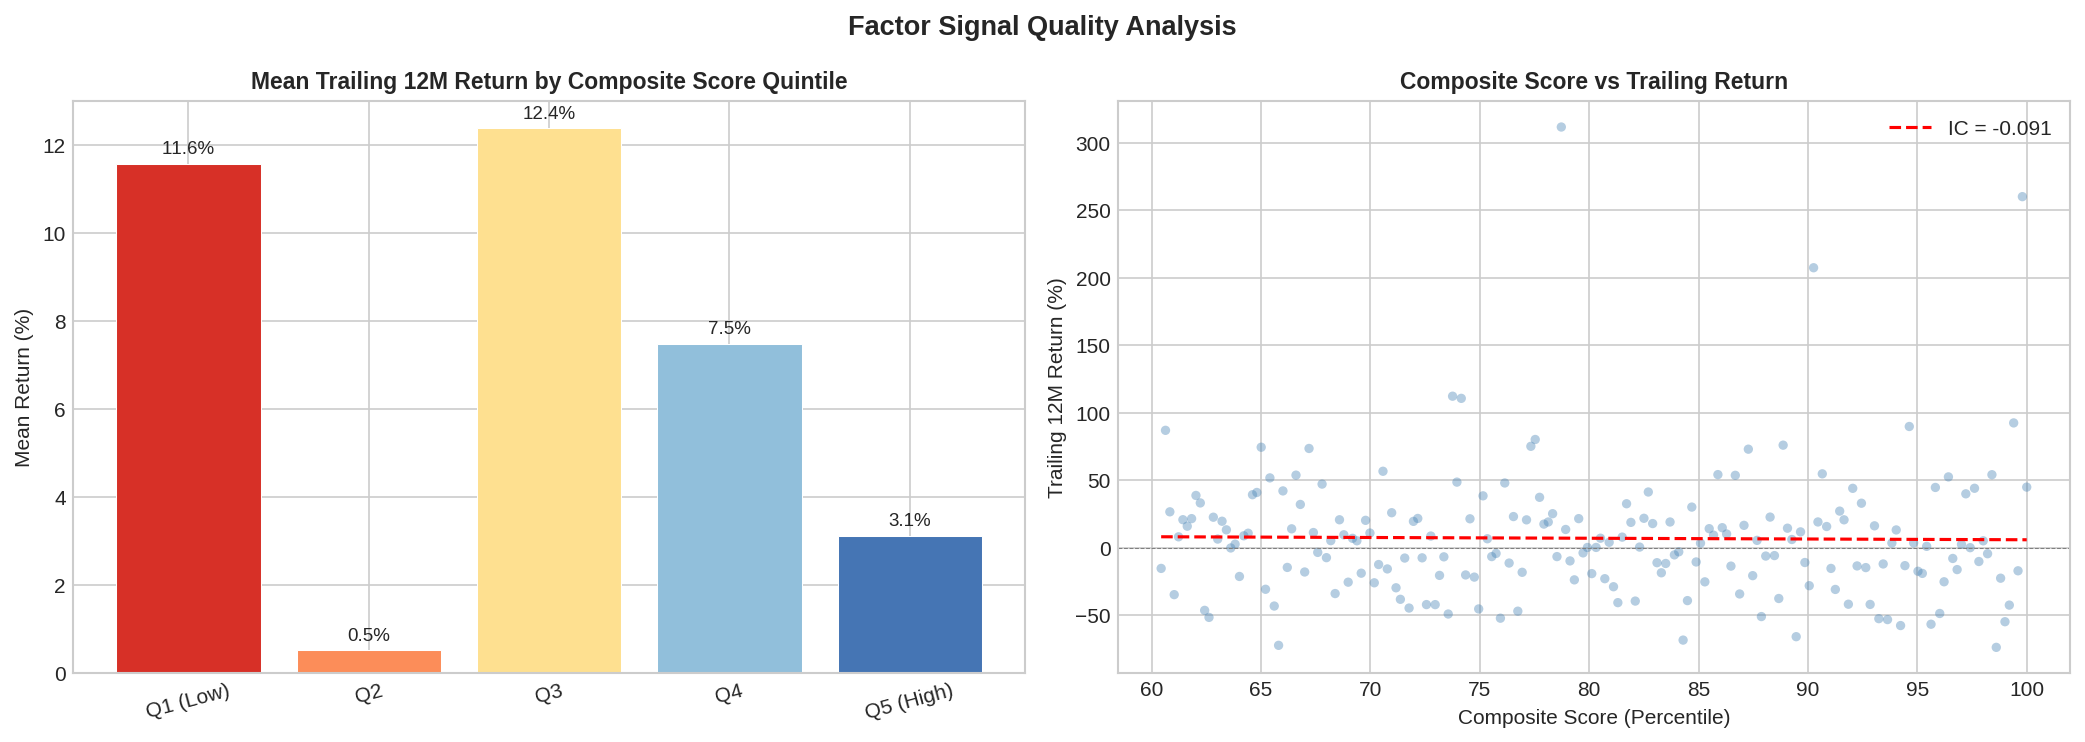

In [41]:
# ── Quintile Return Plot ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=PLOT_DPI)

# Bar: mean return by quintile
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
bars = axes[0].bar(quintile_returns.index,
                   quintile_returns['Mean Return'],
                   color=colors, edgecolor='white', linewidth=0.5)
axes[0].bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=9)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Mean Trailing 12M Return by Composite Score Quintile',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Return (%)')
axes[0].tick_params(axis='x', rotation=15)

# Scatter: composite score vs trailing return
axes[1].scatter(valid['composite_score'], valid['trailing_return_1y'] * 100,
                alpha=0.4, s=20, c='steelblue', edgecolors='none')
# Trend line
z = np.polyfit(valid['composite_score'].dropna(),
               (valid['trailing_return_1y'] * 100).dropna(), 1)
p_line = np.poly1d(z)
x_range = np.linspace(valid['composite_score'].min(), valid['composite_score'].max(), 100)
axes[1].plot(x_range, p_line(x_range), 'r--', linewidth=1.5, label=f'IC = {ic_composite:.3f}')
axes[1].set_xlabel('Composite Score (Percentile)')
axes[1].set_ylabel('Trailing 12M Return (%)')
axes[1].set_title('Composite Score vs Trailing Return', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle('Factor Signal Quality Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'performance_metrics.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

---
# 💾 CELL 10 — Export Final Deliverables

In [42]:
# ============================================================
# CELL 10: Export Results
#
# Produces:
#   1. Full universe CSV
#   2. Top-N watchlist CSV
#   3. Formatted Excel workbook with multiple sheets
#   4. Summary statistics markdown
# ============================================================

import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule

# ── 1. Full universe CSV ──────────────────────────────────────
full_csv_path = OUTPUT_DIR / f'full_universe_ranked_{RUN_TIMESTAMP}.csv'
ranked.to_csv(full_csv_path, index=False)
print(f'✅ Full universe saved: {full_csv_path}')

# ── 2. Top-N watchlist CSV ────────────────────────────────────
watchlist_csv_path = OUTPUT_DIR / f'watchlist_top{TOP_N}_{RUN_TIMESTAMP}.csv'
watchlist.head(TOP_N).to_csv(watchlist_csv_path, index=False)
print(f'✅ Watchlist saved: {watchlist_csv_path}')

# ── 3. Excel workbook ─────────────────────────────────────────
excel_path = OUTPUT_DIR / f'multi_factor_screener_{RUN_TIMESTAMP}.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:

    # Sheet 1: Full Ranked Universe
    ranked.to_excel(writer, sheet_name='Full Universe', index=False)

    # Sheet 2: Top-N Watchlist
    watchlist.head(TOP_N).to_excel(writer, sheet_name=f'Top {TOP_N} Watchlist', index=False)

    # Sheet 3: Sector Summary
    sector_summary = (
        ranked.groupby('sector').agg(
            count=('ticker', 'count'),
            avg_composite=('composite_score', 'mean'),
            avg_value=('value_pct', 'mean'),
            avg_quality=('quality_pct', 'mean'),
            avg_growth=('growth_pct', 'mean'),
            median_pe=('pe_ratio', 'median'),
            median_roe=('roe', 'median'),
            median_rev_cagr=('revenue_cagr', 'median'),
        ).round(2)
        .sort_values('avg_composite', ascending=False)
    )
    sector_summary.to_excel(writer, sheet_name='Sector Summary')

    # Sheet 4: Quintile Analysis
    quintile_returns.to_excel(writer, sheet_name='Quintile Analysis')

    # ── Apply formatting to Top-N sheet ──────────────────────
    wb = writer.book
    ws = wb[f'Top {TOP_N} Watchlist']

    header_fill = PatternFill(start_color='1F3A5F', end_color='1F3A5F', fill_type='solid')
    header_font = Font(bold=True, color='FFFFFF', size=10)
    alt_fill    = PatternFill(start_color='EEF2FF', end_color='EEF2FF', fill_type='solid')

    for cell in ws[1]:  # Header row
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center', vertical='center')

    for row_idx, row in enumerate(ws.iter_rows(min_row=2, max_row=ws.max_row), start=2):
        if row_idx % 2 == 0:
            for cell in row:
                cell.fill = alt_fill

    # Auto-fit column widths
    for col in ws.columns:
        max_len = max((len(str(c.value)) if c.value else 0) for c in col)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 2, 30)

    # Color scale on composite_score column (col E = index 5)
    score_col_letter = get_column_letter(watchlist_cols.index('composite_score') + 1)
    score_range = f'{score_col_letter}2:{score_col_letter}{TOP_N + 1}'
    ws.conditional_formatting.add(
        score_range,
        ColorScaleRule(start_type='min', start_color='FF6347',
                       mid_type='percentile', mid_value=50, mid_color='FFFF00',
                       end_type='max', end_color='00B050')
    )

print(f'✅ Excel workbook saved: {excel_path}')

# ── 4. Summary stats markdown ─────────────────────────────────
summary_md = f"""# Multi-Factor Screener — Run Summary

**Run date:** {RUN_TIMESTAMP}
**Universe:** {len(ranked)} stocks (S&P 500)
**Factor weights:** Value={FACTOR_WEIGHTS['value']:.0%} | Quality={FACTOR_WEIGHTS['quality']:.0%} | Growth={FACTOR_WEIGHTS['growth']:.0%}

## Top 10 Composite Stocks
{ranked[['rank','ticker','company','sector','composite_score']].head(10).to_markdown(index=False)}

## Sector Rankings (by Avg Composite)
{sector_summary[['avg_composite','avg_value','avg_quality','avg_growth']].head().to_markdown()}

## Signal Quality
- Composite IC (Spearman, vs 12M trailing): **{ic_composite:.4f}** (p={p_val:.4f})
- Value IC: {ic_value:.4f} | Quality IC: {ic_quality:.4f} | Growth IC: {ic_growth:.4f}
"""

summary_path = OUTPUT_DIR / f'summary_{RUN_TIMESTAMP}.md'
summary_path.write_text(summary_md)
print(f'✅ Summary saved: {summary_path}')

✅ Full universe saved: /content/screener_output/full_universe_ranked_20260623_0320.csv
✅ Watchlist saved: /content/screener_output/watchlist_top50_20260623_0320.csv
✅ Excel workbook saved: /content/screener_output/multi_factor_screener_20260623_0320.xlsx
✅ Summary saved: /content/screener_output/summary_20260623_0320.md


In [43]:
# ============================================================
# CELL 10b: Download all files from Colab to local machine
# ============================================================

from google.colab import files
import zipfile

# Zip the entire output directory
zip_path = f'/content/multi_factor_screener_{RUN_TIMESTAMP}.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file in OUTPUT_DIR.rglob('*'):
        if file.is_file():
            zf.write(file, file.relative_to(OUTPUT_DIR.parent))

print(f'📦 Zip created: {zip_path}')
files.download(zip_path)
print('✅ Download initiated. Check your browser downloads folder.')

📦 Zip created: /content/multi_factor_screener_20260623_0320.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download initiated. Check your browser downloads folder.


---
# 📋 CELL 11 — Project Summary

In [44]:
# ============================================================
# CELL 11: Print Final Project Summary
# ============================================================

print('=' * 70)
print('  MULTI-FACTOR FUNDAMENTAL SCREENER — COMPLETE')
print('=' * 70)
print(f'  Run timestamp : {RUN_TIMESTAMP}')
print(f'  Universe size : {len(ranked)} stocks (S&P 500)')
print(f'  Top watchlist : Top {TOP_N} by composite score')
print()
print('  FACTOR WEIGHTS')
print(f'    Value   : {FACTOR_WEIGHTS["value"]:.0%}  (P/E, P/B, EV/EBITDA, P/FCF)')
print(f'    Quality : {FACTOR_WEIGHTS["quality"]:.0%}  (ROE, ROIC, Gross Margin Stability, D/E)')
print(f'    Growth  : {FACTOR_WEIGHTS["growth"]:.0%}  (Revenue CAGR, EPS CAGR, FCF CAGR)')
print()
print('  SIGNAL QUALITY')
print(f'    Composite IC vs 12M Return : {ic_composite:.4f}')
print(f'    Value IC                   : {ic_value:.4f}')
print(f'    Quality IC                 : {ic_quality:.4f}')
print(f'    Growth IC                  : {ic_growth:.4f}')
print()
print('  OUTPUT FILES')
for f in sorted(OUTPUT_DIR.rglob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f'    {f.name:<45} {size_kb:>7.1f} KB')
print()
print('  TOP 10 COMPOSITE STOCKS')
print(ranked[['rank','ticker','company','composite_score','value_pct','quality_pct','growth_pct']]
      .head(10).to_string(index=False))
print('=' * 70)

  MULTI-FACTOR FUNDAMENTAL SCREENER — COMPLETE
  Run timestamp : 20260623_0320
  Universe size : 503 stocks (S&P 500)
  Top watchlist : Top 50 by composite score

  FACTOR WEIGHTS
    Value   : 33%  (P/E, P/B, EV/EBITDA, P/FCF)
    Quality : 33%  (ROE, ROIC, Gross Margin Stability, D/E)
    Growth  : 34%  (Revenue CAGR, EPS CAGR, FCF CAGR)

  SIGNAL QUALITY
    Composite IC vs 12M Return : -0.0907
    Value IC                   : -0.1493
    Quality IC                 : -0.1724
    Growth IC                  : 0.1392

  OUTPUT FILES
    factor_correlation.png                          167.5 KB
    factor_distributions.png                        106.1 KB
    full_universe_ranked_20260623_0320.csv          382.6 KB
    multi_factor_screener_20260623_0320.xlsx        280.4 KB
    performance_metrics.png                         122.3 KB
    pillar_distribution_by_sector.png               110.5 KB
    radar_top6.png                                  409.4 KB
    raw_data_checkpoint.csv       

---

## 12. Performance Metrics — What This Measures

| Metric | Description |
|--------|-------------|
| **Information Coefficient (IC)** | Spearman rank correlation between composite score and trailing 12M return. IC > 0.05 is considered meaningful for a single cross-section. |
| **Quintile Spread** | Return difference between top-quintile and bottom-quintile composite stocks. A positive spread validates the factor. |
| **Sharpe (simple)** | Mean quintile return / std dev — a rough risk-adjusted signal quality metric. |

> ⚠️ **Important caveat:** Trailing return correlation does NOT prove predictive power. It is a diagnostic showing whether the current snapshot of scores aligns with recent price history. A proper backtest requires point-in-time fundamental data (Compustat/FactSet) to avoid look-ahead bias.

---

## 13. Final Deliverables

| File | Description |
|------|-------------|
| `full_universe_ranked_*.csv` | All ~500 stocks ranked by composite score with all raw metrics |
| `watchlist_top50_*.csv` | Clean CSV of the top 50 screened stocks |
| `multi_factor_screener_*.xlsx` | Formatted Excel workbook: Full universe + Watchlist + Sector summary + Quintile analysis |
| `summary_*.md` | Markdown summary of run results |
| `*.png` charts | Static charts: distributions, heatmaps, radar, quintile returns |
| `*.html` files | Interactive Plotly charts (scatter, table, histogram) |

---

## 14. Resume Description

```
Multi-Factor Fundamental Screener | Python, pandas, yfinance, Plotly | 2024
• Built a cross-sectional quantitative screener ranking 500 S&P 500 stocks on
  Value (P/E, EV/EBITDA, P/FCF), Quality (ROIC, gross margin stability), and
  Growth (revenue/EPS/FCF CAGR) using a weighted Z-score composite.
• Engineered a robust data pipeline (yfinance) with rate-limit handling,
  checkpoint recovery, Winsorization, and sector-median imputation.
• Validated signal quality via Spearman IC analysis and quintile spread vs
  trailing 12-month returns, producing interactive Plotly dashboards and
  color-formatted Excel watchlists for analyst distribution.
```

---

## 15. Potential Upgrades

| Upgrade | Description | Complexity |
|---------|-------------|------------|
| **Point-in-time data** | Replace yfinance with Compustat/FactSet for survivorship-bias-free backtest | High |
| **Dynamic factor weights** | Use ICIR-weighted optimization to tilt toward factors with recent predictive power | Medium |
| **Sector-neutral scoring** | Z-score within sector rather than cross-sectionally to remove industry beta | Low |
| **Sentiment overlay** | Add earnings revision momentum (Estimize/Refinitiv consensus) as a 4th pillar | Medium |
| **ML ranking** | Train LightGBM/XGBoost on factor features to predict next-quarter excess returns | High |
| **Portfolio construction** | Add risk-parity or mean-variance weighting on top-N watchlist | Medium |
| **Scheduled refresh** | Deploy on Google Cloud Run with weekly Pub/Sub trigger | Medium |
| **Alerts** | Email/Slack alert when a stock crosses into Top 50 or drops out | Low |
